In [ ]:
import marimo as mo
from glob import glob
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    style='white', palette='Dark2',
    rc={"figure.dpi": 300}
)
import itertools
import pingouin as pg
import librosa
from scipy.signal import resample, savgol_filter
from scipy.stats import zscore
import os
from scipy.signal import correlate, correlation_lags
from mtrf.model import TRF
from mtrf.stats import nested_crossval
import numpy as np
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
lme4 = importr("lme4")
base = importr("base")
import uuid
import tqdm

# from sklearn.manifold import MDS
# from sklearn.cluster import KMeans
# from adjustText import adjust_text
# import cv2

# Study 1

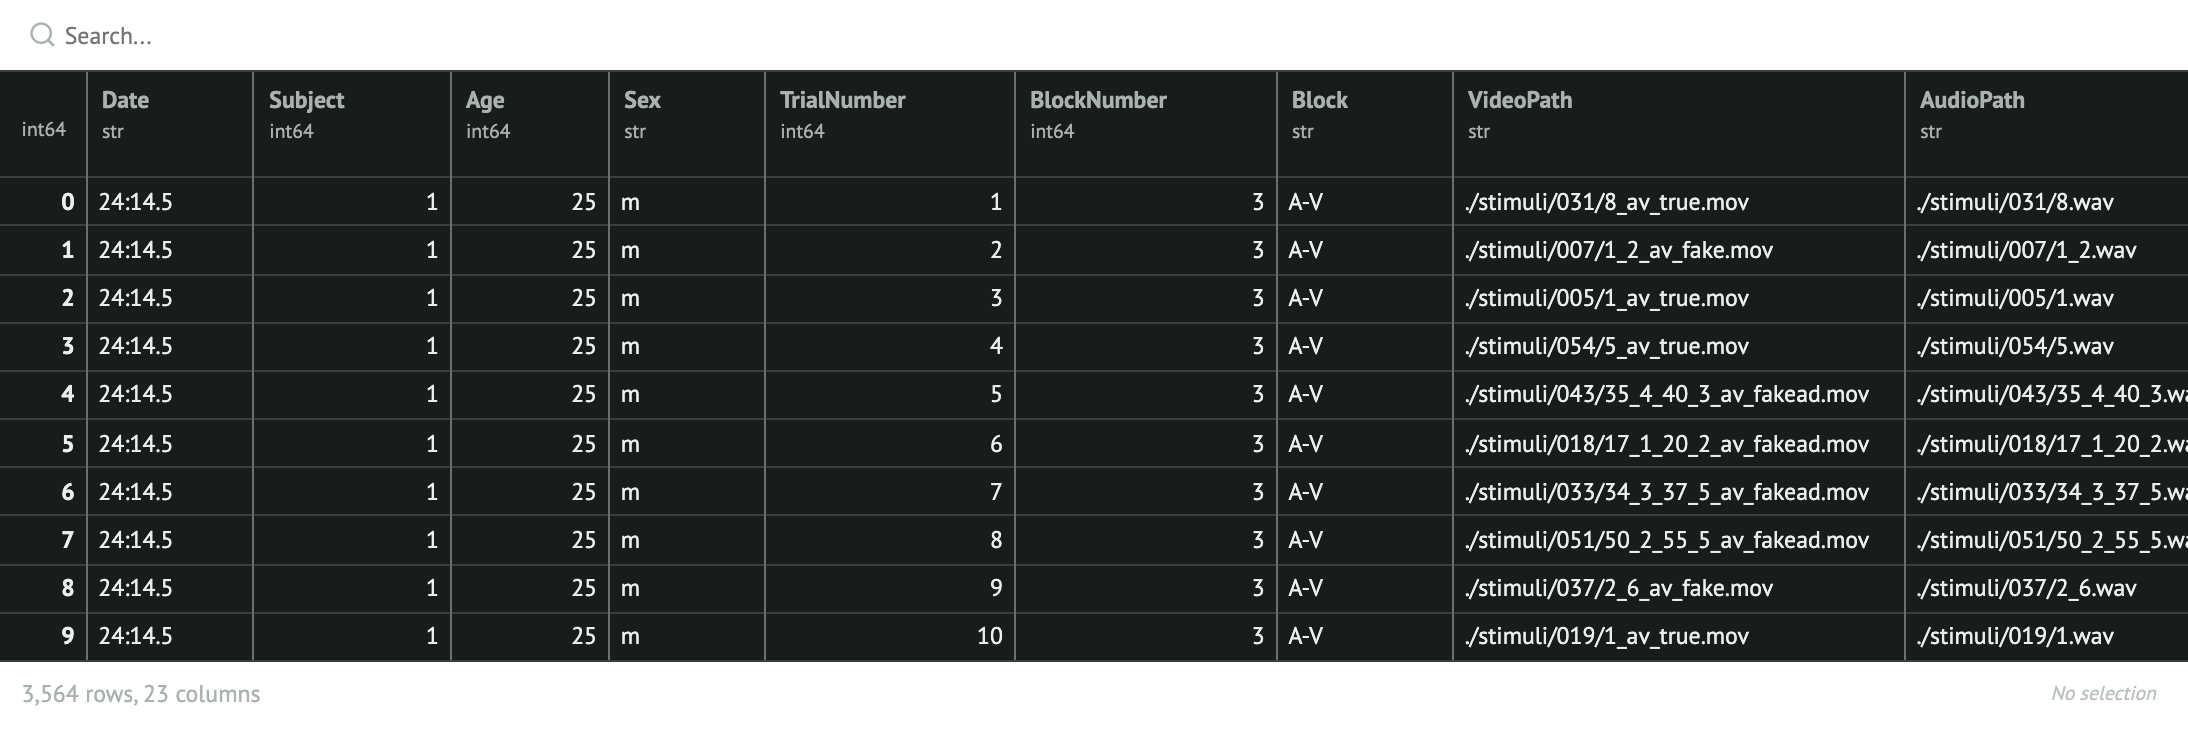

In [ ]:
study1_df = pd.concat([
    pd.read_csv(x)
    for x in sorted(glob("./responses/study1/*.csv"))
])
# if csv file is opened in Excel it (infuriatingly) changes 'true' to a boolean TRUE 
# so fix that
study1_df["Condition"] = study1_df.Condition.transform(lambda x: "true" if str(x).lower() == "true" else "fake")
study1_df["CorrectResp"] = study1_df.Condition.transform(lambda x: 'g' if x=="true" else "h")
study1_df["ListenerSex"] = study1_df.SpeakerSex.transform(lambda x: "F" if x=="M" else "M")
study1_df

## Demographics

In [ ]:
demo = study1_df.groupby("Subject").agg({"Age": "first", "Sex": "first"})
demo_m = demo.loc[demo.Sex=="m"]
demo_f = demo.loc[demo.Sex=="f"]

print(
    f"""
    N={len(demo)} (M={demo.Age.mean():.2f}, SD={demo.Age.std():.2f})
    N_male={len(demo_m)} (M={demo_m.Age.mean():.2f}, SD={demo_m.Age.std():.2f})
    N_female={len(demo_f)} (M={demo_f.Age.mean():.2f}, SD={demo_f.Age.std():.2f})
    """
)


    N=18 (M=25.78, SD=10.04)
    N_male=14 (M=25.93, SD=11.32)
    N_female=4 (M=25.25, SD=3.95)
    


## Behavioural results

In [ ]:
def sdt_category(data):
    '''
    Task: Was the interaction you watched a genuine interaction? Press 'g' if yes, 'h' if no.
    '''
    match (data.CorrectResp, data.Resp):
        case ("g", "g"):
            return "hit"
        case ("g", "h"):
            return "miss"
        case ("h", "h"):
            return "cr"
        case ("h", "g"):
            return "fa"
        case _:
            raise ValueError("CorrectResp and Resp values can only be g or h")

In [ ]:
def sdt_rates(data):
    n_hit = len(data.loc[data=="hit"])
    n_miss = len(data.loc[data=="miss"])
    n_cr = len(data.loc[data=="cr"])
    n_fa = len(data.loc[data=="fa"])

    hit_rate = (n_hit) / (n_hit + n_miss)
    fa_rate = (n_fa) / (n_fa + n_cr)
    dprime = stats.norm.ppf(hit_rate) - stats.norm.ppf(fa_rate)
    accuracy = (n_hit + n_cr) / len(data)

    return pd.DataFrame({
        "hit_rate": [hit_rate], "fa_rate": [fa_rate], 
        "dprime": [dprime], "accuracy": [accuracy]
    })

In [ ]:
def pairwise_ttest(data, dv, between, paired=False):
    results = []
    for c1, c2 in itertools.combinations(data[between].unique(), 2):
        res = pg.ttest(
            data.loc[data[between]==c1][dv],
            data.loc[data[between]==c2][dv],
            paired=paired
        )
        res["comparison"] = f"{c1} | {c2}"
        results.append(res)

    return pd.concat(results)

In [ ]:
study1_df["SDT"] = study1_df.apply(sdt_category, axis=1)
dprime_df = study1_df.groupby(["Subject", "Block"], as_index=False).SDT.apply(sdt_rates)

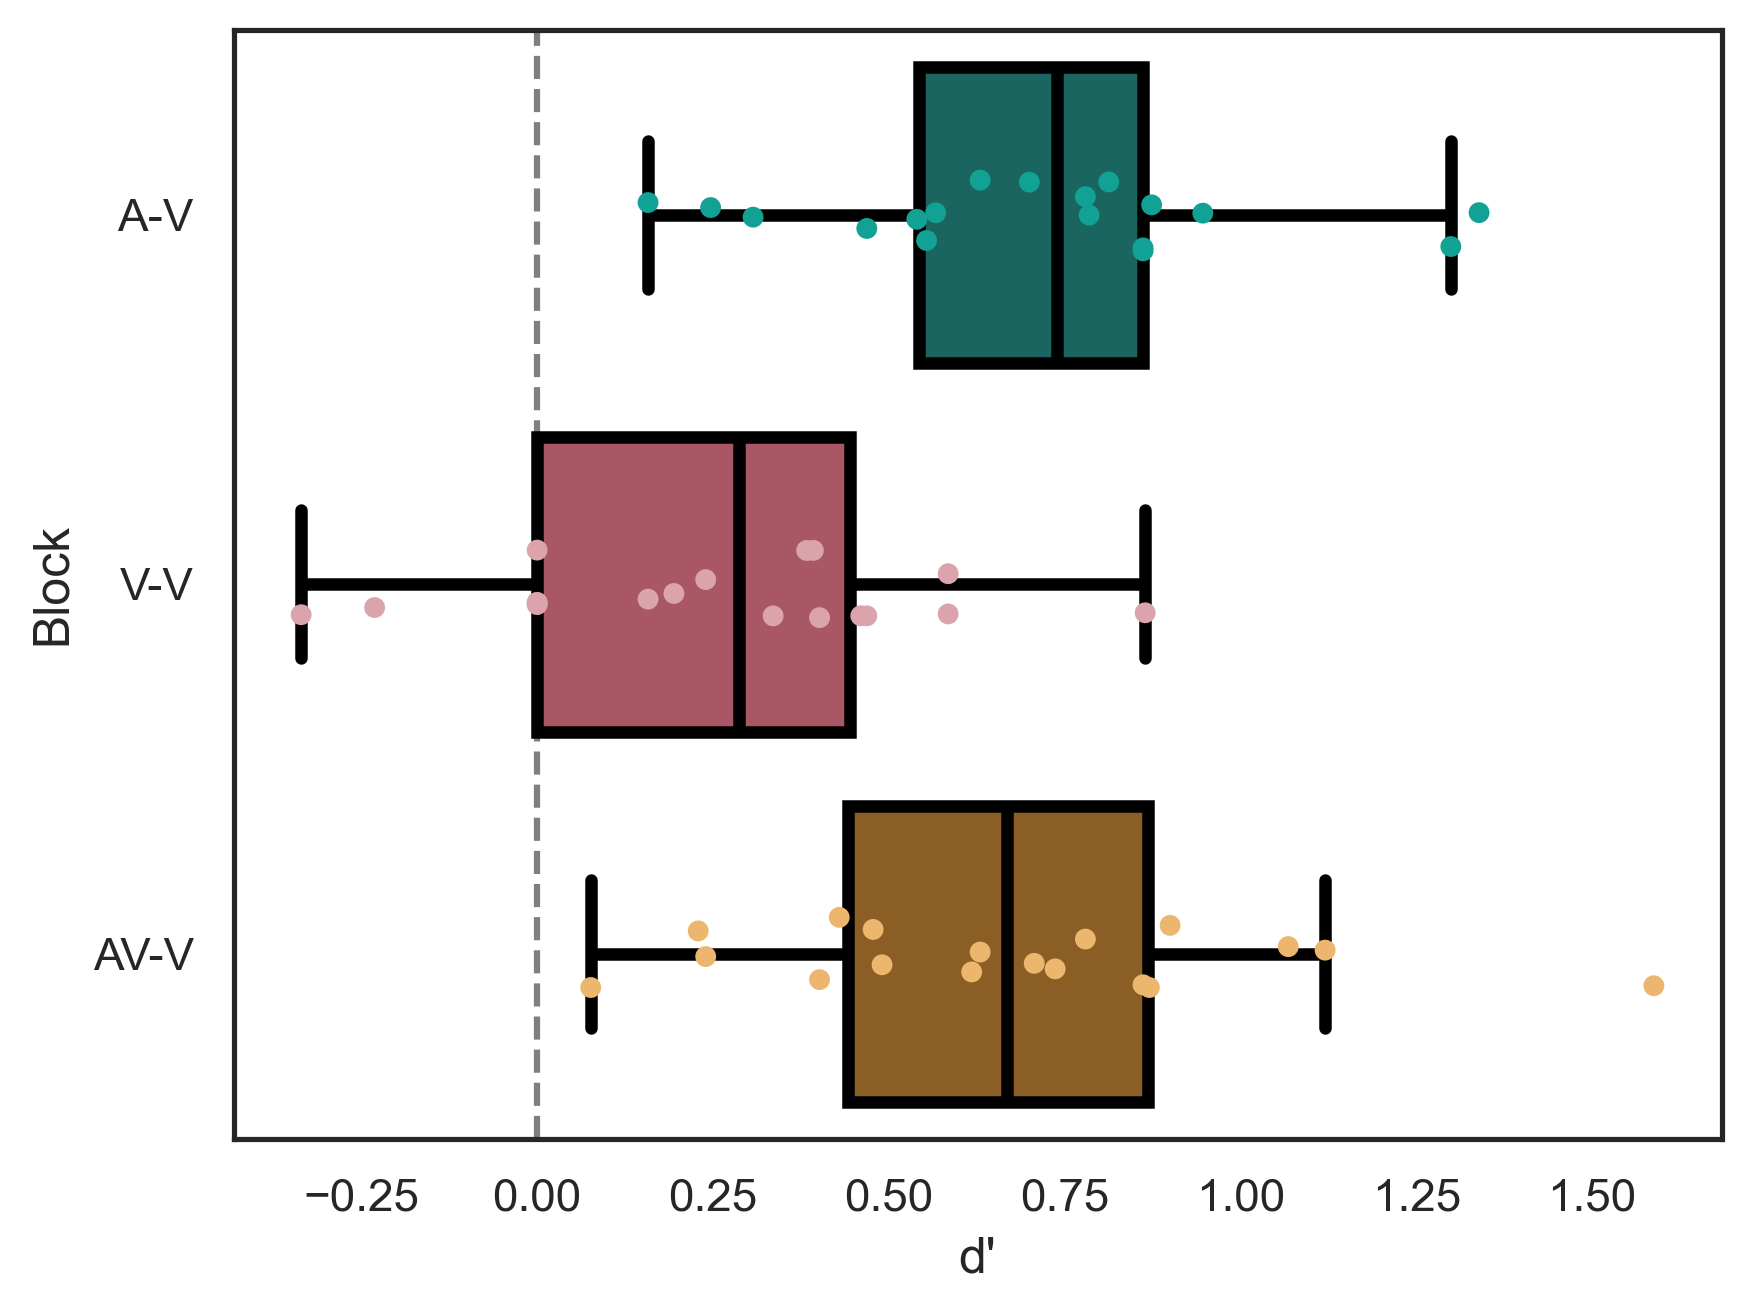

In [ ]:
sns.boxplot(
    data=dprime_df, y="Block", x="dprime", hue="Block", 
    order=["A-V", "V-V", "AV-V"], fill=True,
    palette=["#0d7269", "#9b6013", "#b64a5c"],
    fliersize=0, linewidth=3, linecolor="k"
)
sns.stripplot(data=dprime_df, y="Block", x="dprime", hue="Block", palette=["#12a195", "#edb66e", "#dba4ad"], jitter=True)
plt.axvline(x=0, c="k", ls="--", alpha=0.5)
plt.xlabel("d'")

In [ ]:
import ptitprince as pt

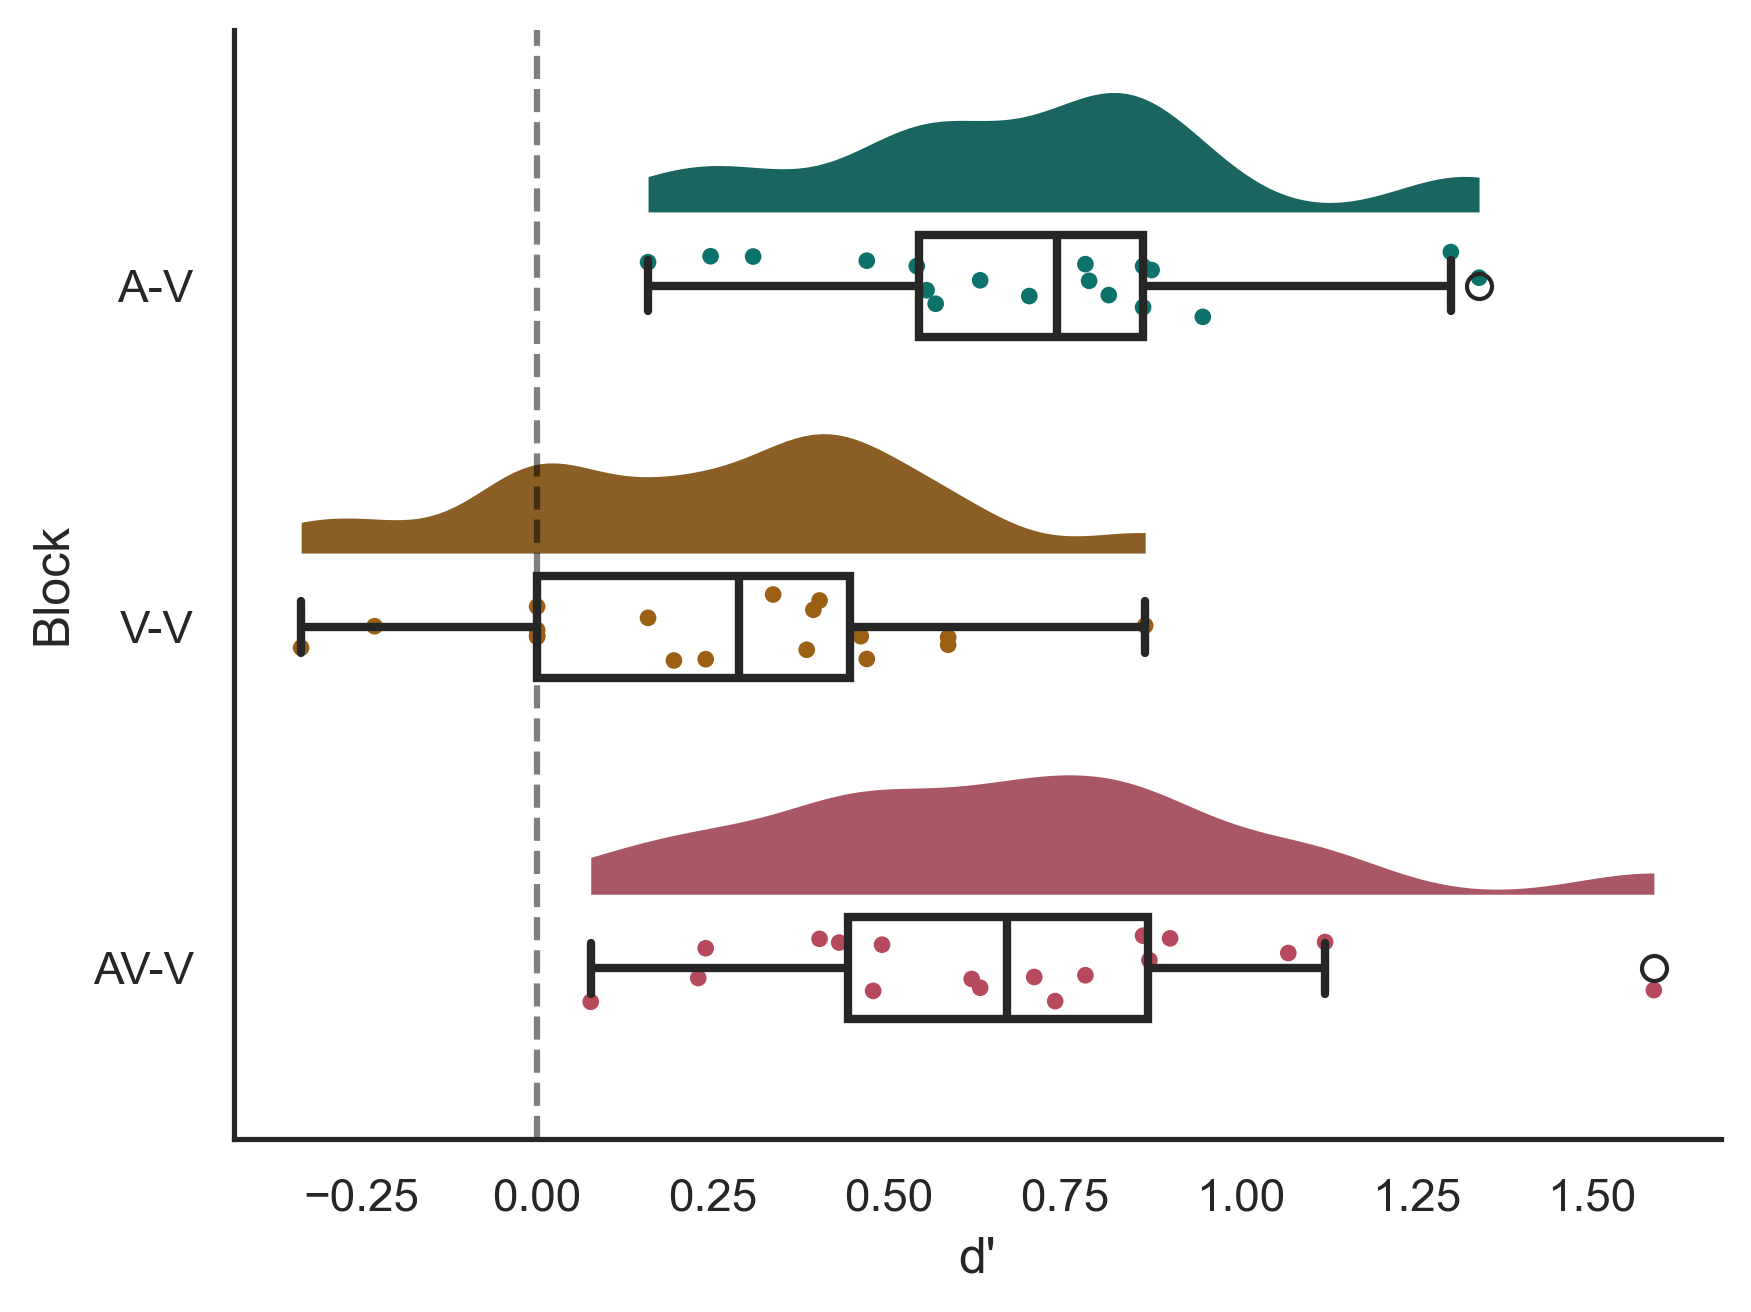

In [ ]:
pt.RainCloud(
    data=dprime_df, x="Block", y="dprime", palette=["#0d7269", "#9b6013", "#b64a5c"], hue="Block", orient="h",
    order=["A-V", "V-V", "AV-V"], hue_order=["A-V", "V-V", "AV-V"], linewidth=0, bw=0.3, 
    width_box=0.3, box_linewidth=2, point_size=4
)
plt.axvline(x=0, c="k", ls="--", alpha=0.5)
plt.xlabel("d'")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gcf()

### Observers can recognize genuine interactions even with severely degraded stimuli

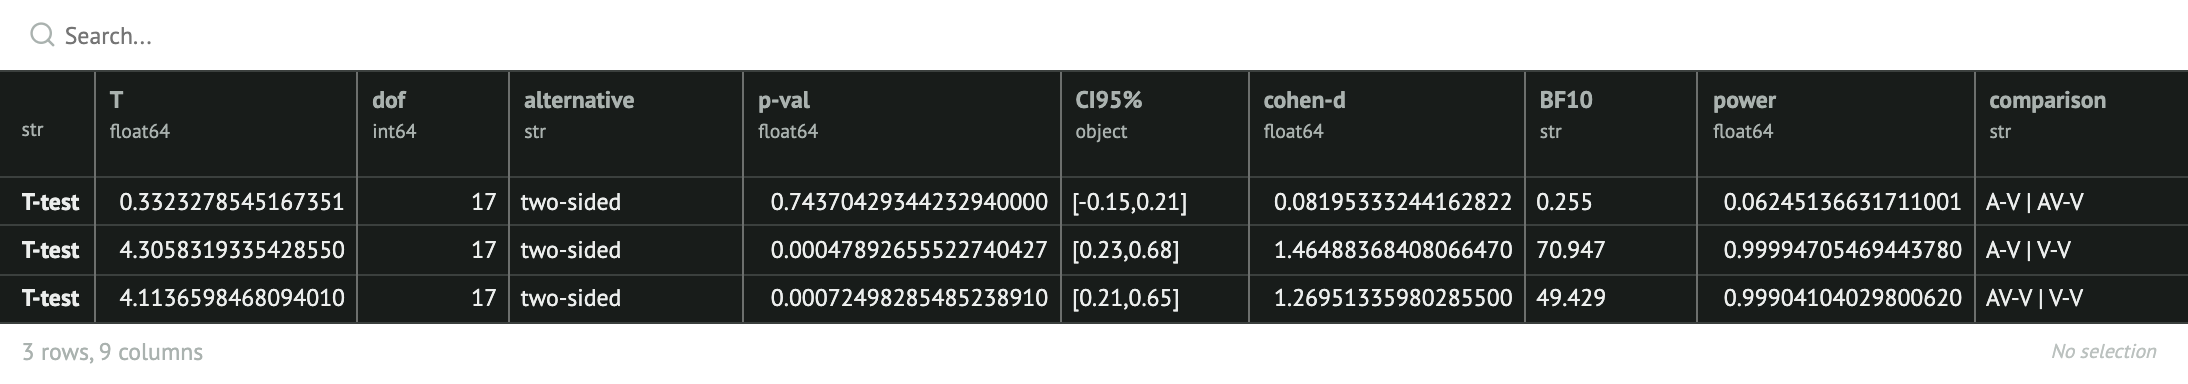

In [ ]:
pairwise_ttest(data=dprime_df, dv="dprime", between="Block", paired=True)

### Being able to see a female speaker negatively impacts observers’ performance

In [ ]:
dprime_df_ls = study1_df.groupby(["Subject", "Block", "ListenerSex"], as_index=False).SDT.apply(sdt_rates)

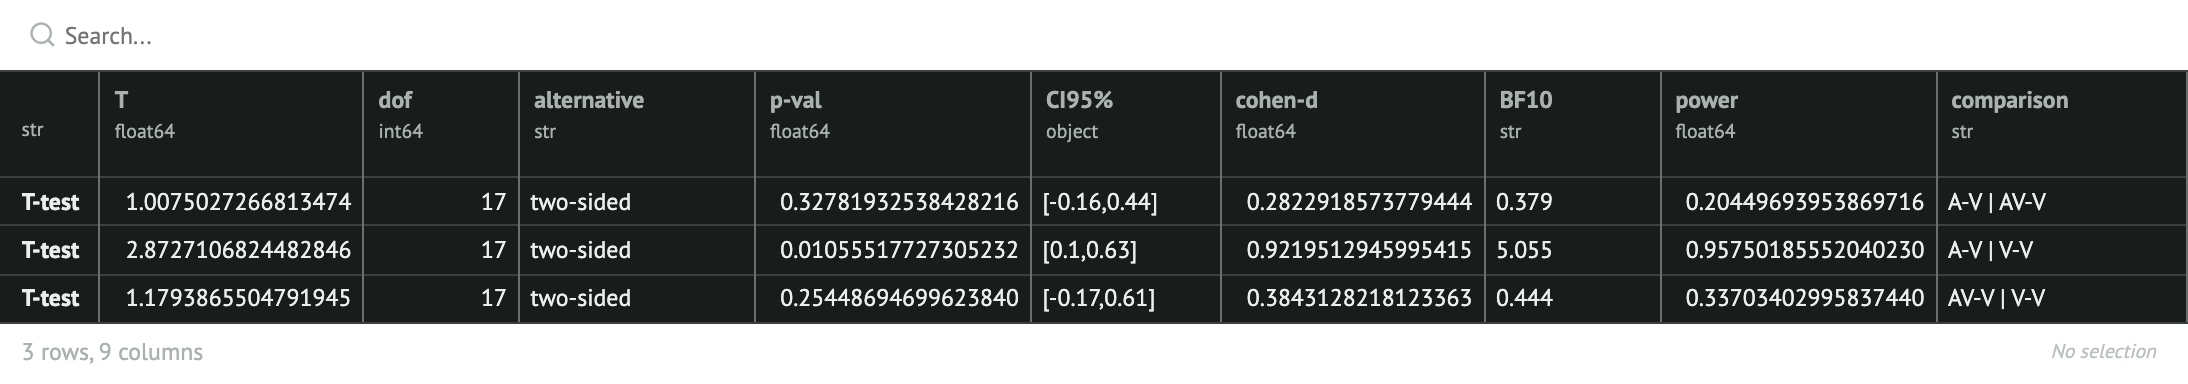

In [ ]:
pairwise_ttest(data=dprime_df_ls.loc[(dprime_df_ls.ListenerSex=="M")], dv="dprime", between="Block", paired=True)

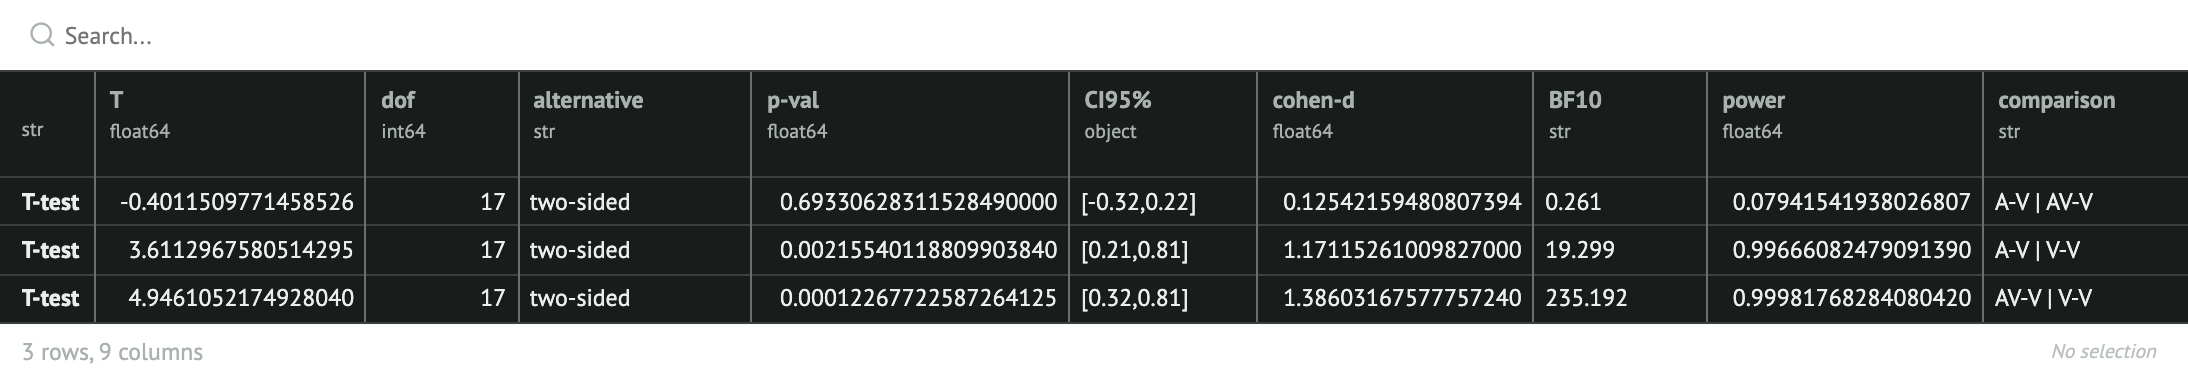

In [ ]:
pairwise_ttest(data=dprime_df_ls.loc[(dprime_df_ls.ListenerSex=="F")], dv="dprime", between="Block", paired=True)

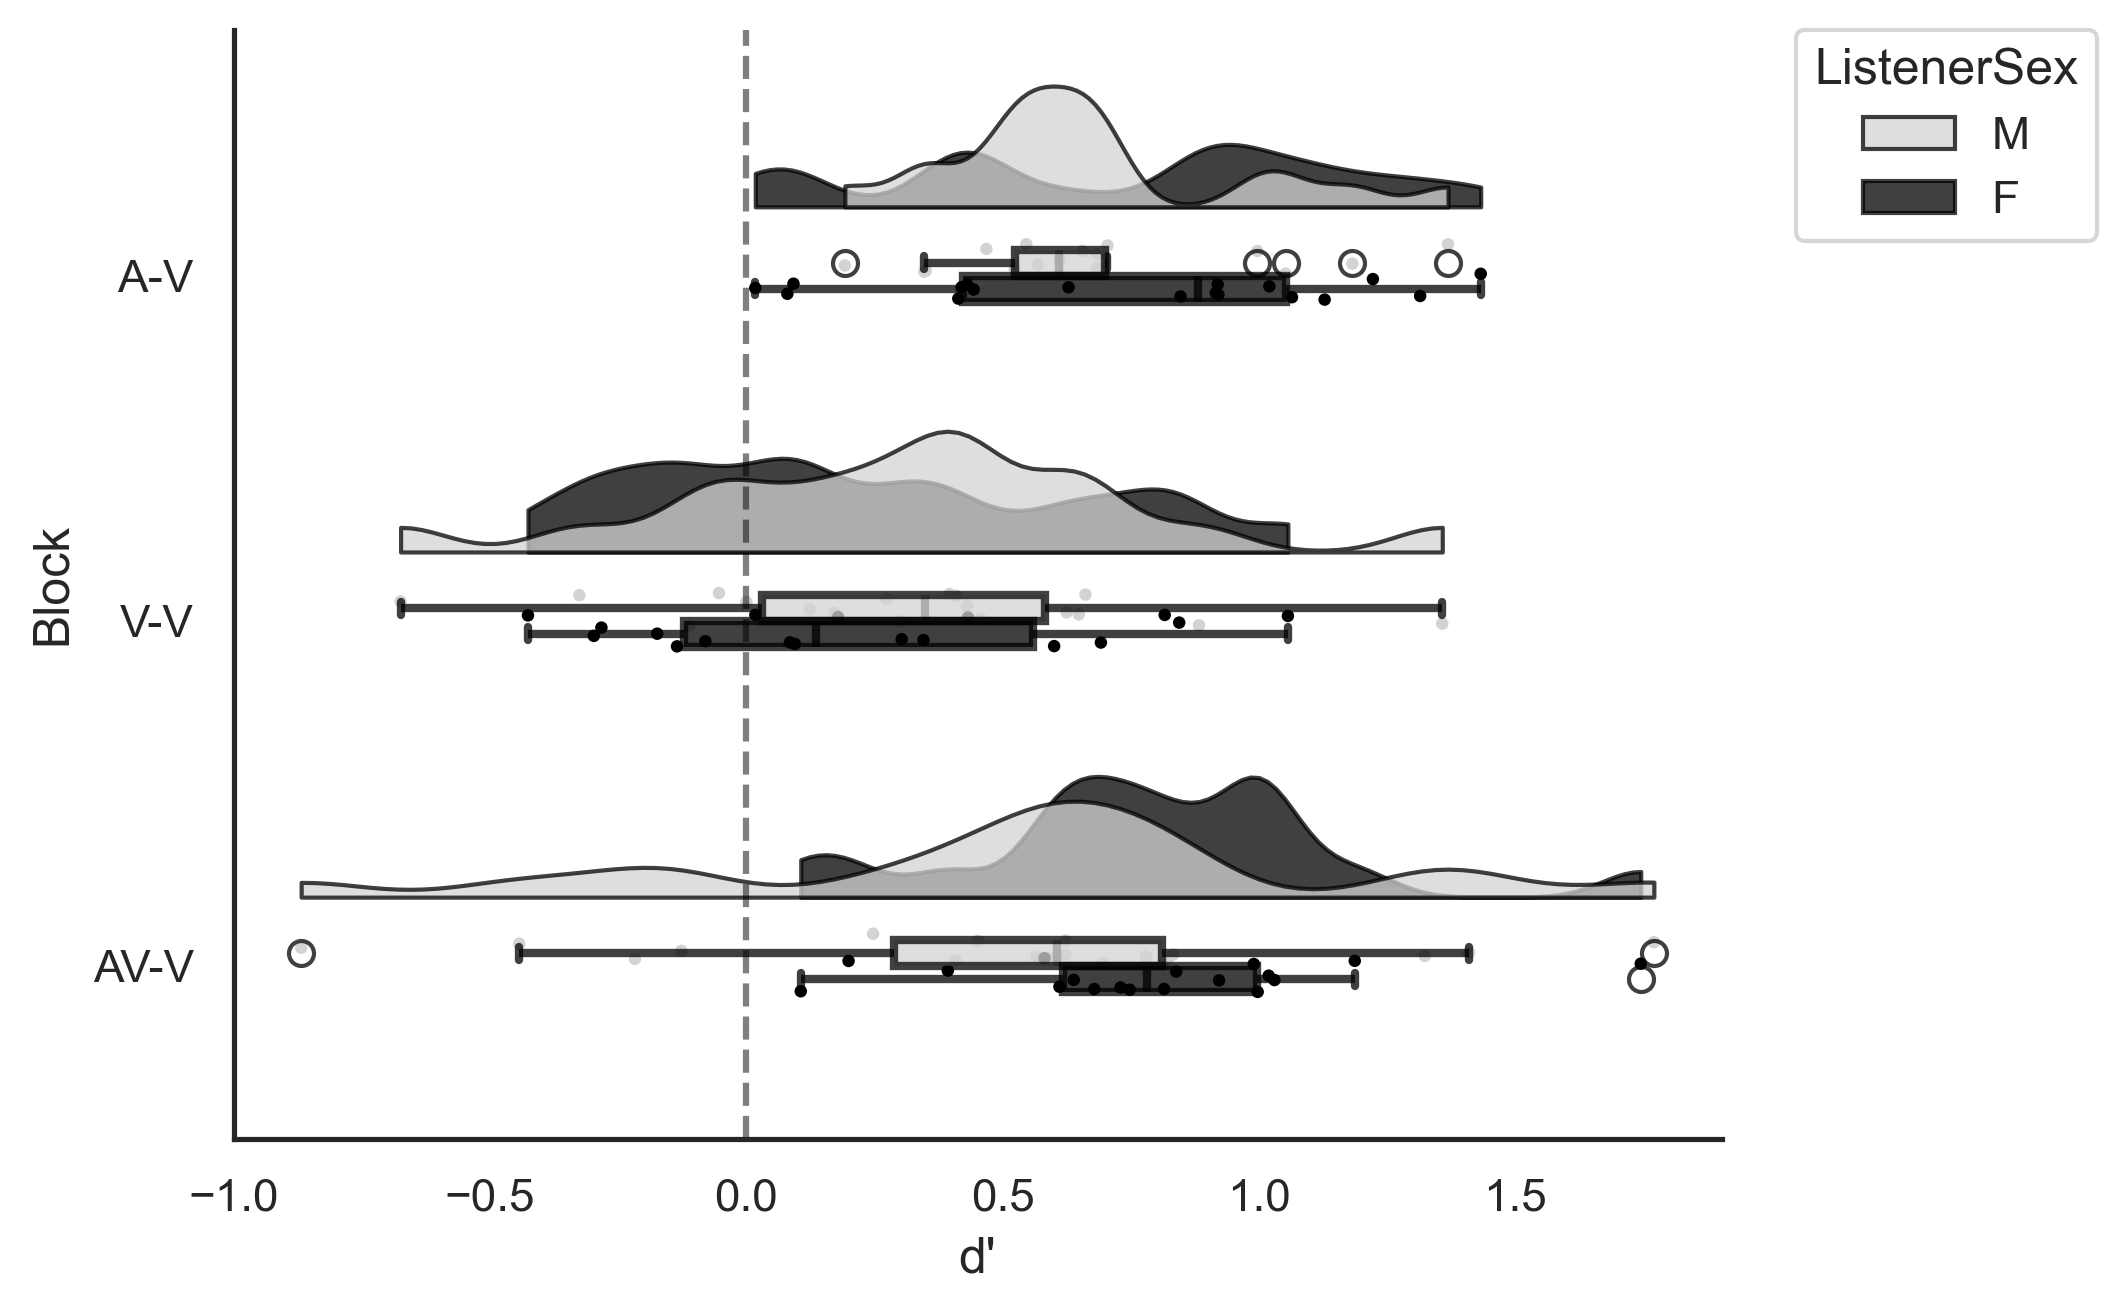

In [ ]:
pt.RainCloud(
    data=dprime_df_ls, x="Block", y="dprime", hue="ListenerSex", orient="h",
    palette=["lightgray", "k"], hue_order=["M", "F"],
    order=["A-V", "V-V", "AV-V"], dodge=True, alpha=0.75, box_linewidth=2, box_fill=True
)   
plt.axvline(x=0, c="k", ls="--", alpha=0.5)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.xlabel("d'")

## TRF analysis: speech -> listener motion

In [ ]:
def extract_audio_feature(sound_file, feature, target_sr, frame_length=2048, hop_length=128):
    y, original_sr = librosa.load(sound_file, sr=None)
    duration = librosa.get_duration(path=sound_file)

    match feature:
        case "rms":
            data = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=int(original_sr/target_sr))[0]
        case "an":
            data = pd.read_csv(sound_file.replace(".wav", ".csv"), usecols=[1]).to_numpy()
        case _:
            raise ValueError(f"feature={feature} not a valid argument.")

    data = resample(data, num=int(target_sr*duration))
    data = zscore(data)

    return data.flatten()

In [ ]:
def get_motion_data(file, resample_length=None):
    name, ext = os.path.splitext(file)
    if ext == ".wav":
        id = name        
    elif ext == ".mov":
        id = "_".join(name.split("_")[:-2])
    else:
        raise ValueError(f"file must be either .mov or .wav, not {ext}")

    motion = pd.read_parquet(f"{id}_motion.gzip")
    motion = motion.rename(columns={"motion": "Motion"})
    if resample_length is not None:
        motion["Motion"] = motion.Motion.apply(lambda x: resample(x, num=resample_length))
    # data["Motion"] = motion.Motion.iloc[0]

    return motion

In [ ]:
def xcorr(a, b, max_abs=True):
    # normalize stimulus and response
    # so xcorr coefs are [-1, 1], i.e. like Pearson r coefs
    stim = a / np.linalg.norm(a)
    resp = b / np.linalg.norm(b)
    xcorr = correlate(stim, resp, mode="full")
    lags = correlation_lags(len(stim), len(resp))
    # only take positive lags
    mask = lags>=0
    lags = lags[mask]
    xcorr = xcorr[mask]
    # return correlation coefficient at time lag at which it was highest
    if max_abs:
        best_lag = lags[np.argmax(np.abs(xcorr))]
        best_lag_corr = xcorr[np.argmax(np.abs(xcorr))]
    else:
        best_lag = lags[np.argmax(xcorr)]
        best_lag_corr = xcorr[np.argmax(xcorr)]

    return best_lag, best_lag_corr

In [ ]:
def train_single_trf(data, input_col, output_col, min_lag, max_lag, sr, reg=None, trim=False, scale=False):
    stimulus = data[input_col].to_list()
    response = data[output_col].to_list()

    trf = TRF(direction=1)
    if reg is None:        
        _, reg = nested_crossval(
            trf, stimulus, response, fs=sr, tmin=min_lag, tmax=max_lag, 
            regularization=np.logspace(-1, 6, 20), k=5, 
            verbose=False, seed=4 
        )
    trf.train(stimulus=stimulus, response=response, fs=sr, tmin=min_lag, tmax=max_lag, regularization=reg)

    if trim:
        # trim the extended parts to remove regression artifacts at the edges
        before = int((0 - min_lag) * sr)
        after = -int((max_lag - 3) * sr)
        trf.times = trf.times[before:None if after==0 else after]
        trf.weights = trf.weights[:, before:None if after==0 else after, :]    
    if scale:
        # scale weights to [-1, 1]
        for i in range(len(trf.weights)):
            trf.weights[i] = MaxAbsScaler().fit_transform(trf.weights[i])

    return trf

In [ ]:
def trf_to_df(trf, label=""):
    df = pd.DataFrame({
        "times": trf.times,
        "weights": trf.weights.flatten()
    })
    if label:
        df["label"] = label

    return df

In [ ]:
SPEECH_FEATURE = "rms"
SR = 30
MIN_LAG = -0.5
MAX_LAG = 3.5

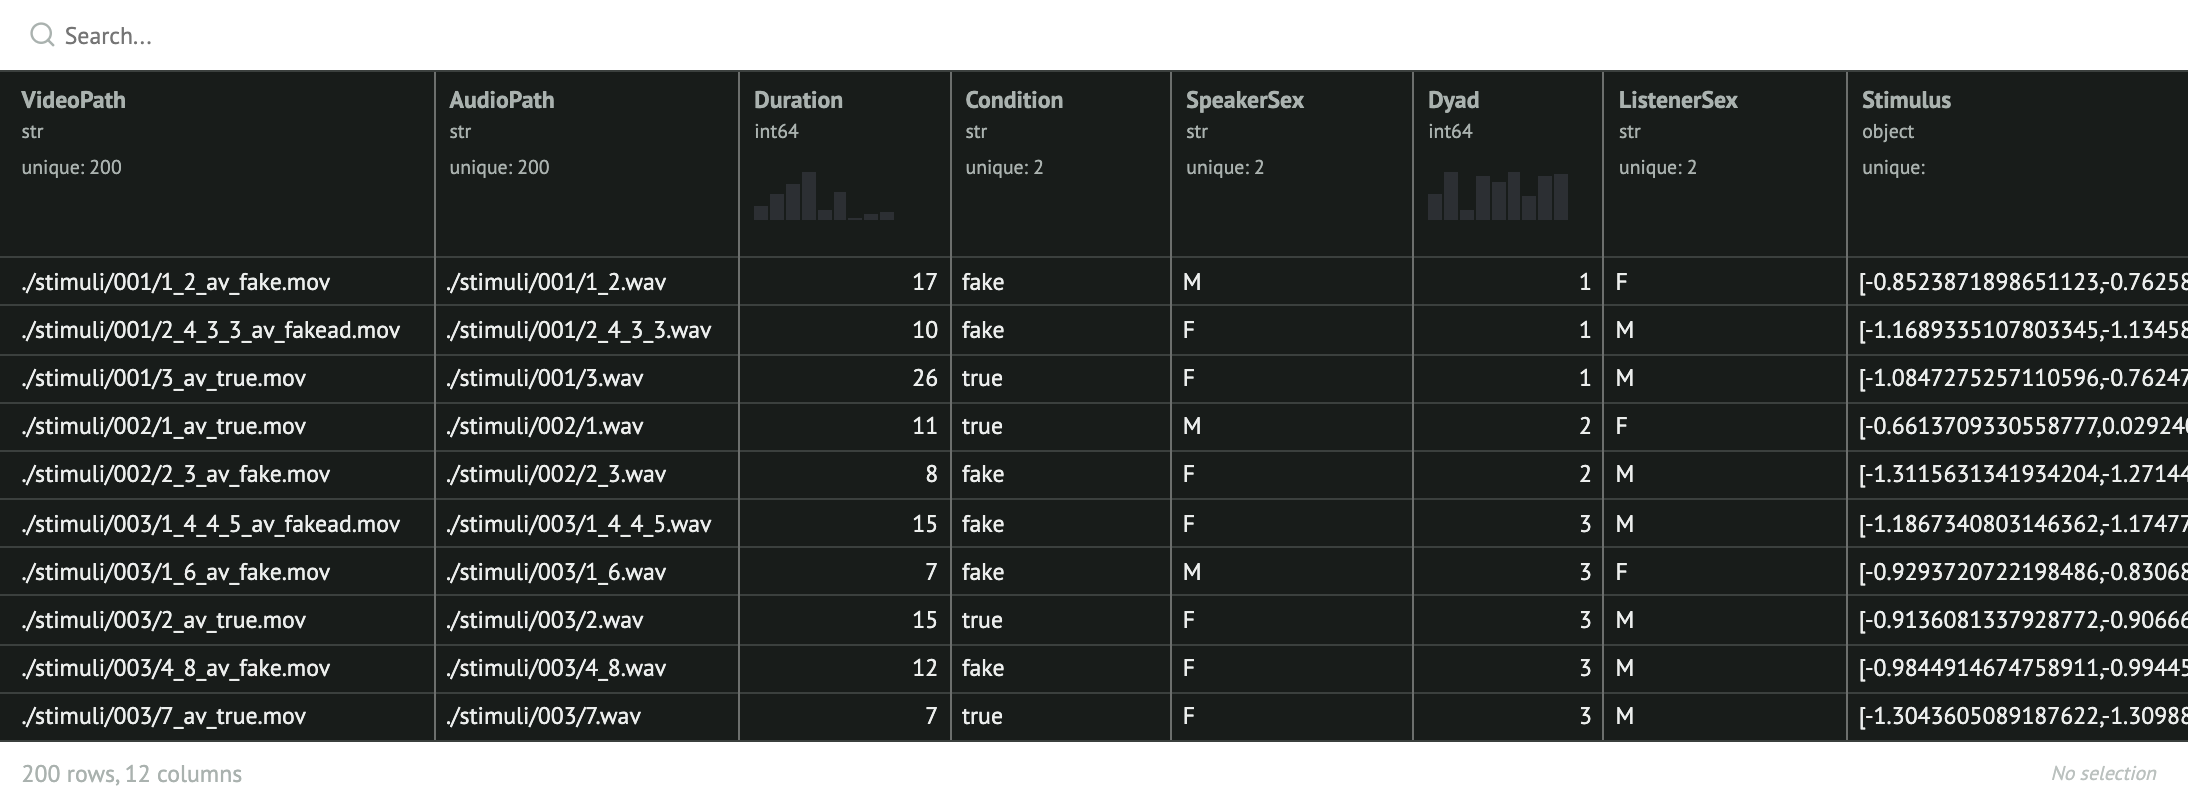

In [ ]:
df = study1_df.loc[(study1_df.Block=="A-V")]
# trial-level data so take the first instance of each trial
df = df.groupby("VideoPath").agg("first")[["AudioPath", "Duration", "Condition", "SpeakerSex", "DisplayedDyad"]].reset_index()
df = df.rename(columns={"DisplayedDyad": "Dyad"})
df["ListenerSex"] = df.SpeakerSex.transform(lambda x: "F" if x=="M" else "M")
# add input column with speech feature
df["Stimulus"] = df.AudioPath.transform(lambda x: extract_audio_feature(x, feature=SPEECH_FEATURE, target_sr=SR))
# add output columns with listeners' motion
# df["Motion"] = df.apply(lambda x: get_motion_data(x.VideoPath, resample_length=len(x.Stimulus)).Motion, axis=1)
df["Motion"] = df.apply(lambda x: get_motion_data(x.VideoPath, resample_length=len(x.Stimulus)).Motion.iloc[0], axis=1)
# add column for intensity as control
df["Intensity"] = df.Motion.transform(lambda x: np.mean(np.abs(x)))
# add column for lagged cross-correlation between input and output as control
df[["best_lag", "xCorr"]] = df.apply(lambda x: xcorr(x.Stimulus, x.Motion, max_abs=True), axis=1, result_type="expand")
# standardize each response individually
df["Motion"] = df.Motion.transform(zscore)
df

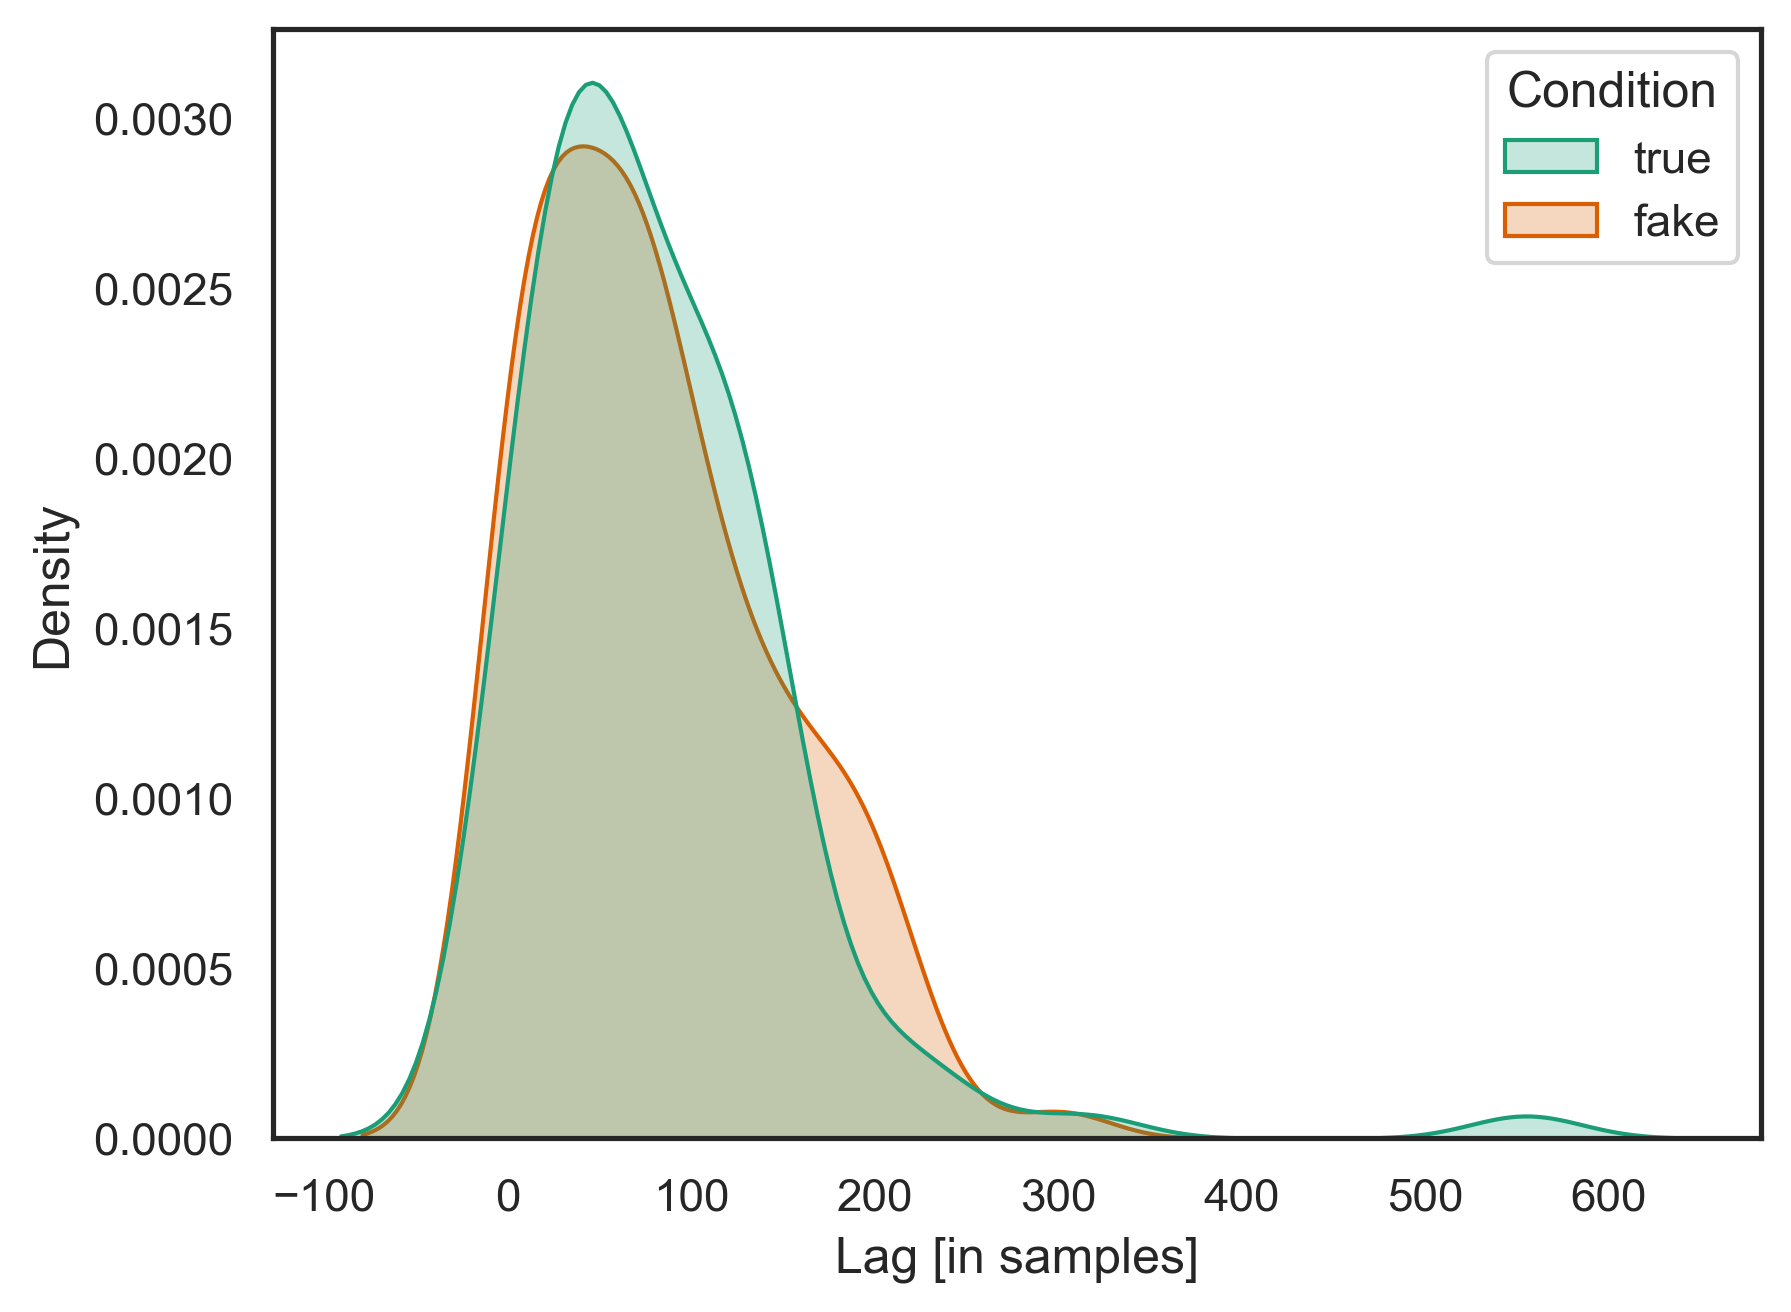

In [ ]:
sns.kdeplot(data=df, x="best_lag", hue="Condition", fill=True, hue_order=["true", "fake"])
plt.xlabel("Lag [in samples]")

### TRF dynamics suggests listener motion tends to peak during pauses or low-intensity periods in speech

In [ ]:
motion_trf = train_single_trf(
    data=df.loc[df.Condition=="true"], input_col="Stimulus", output_col="Motion",
    min_lag=MIN_LAG, max_lag=MAX_LAG, sr=SR, reg=50,
    trim=True, scale=False
)
motion_trf_df = trf_to_df(motion_trf)
motion_trf_df["weights_smooth"] = savgol_filter(motion_trf_df.weights, window_length=5, polyorder=1)

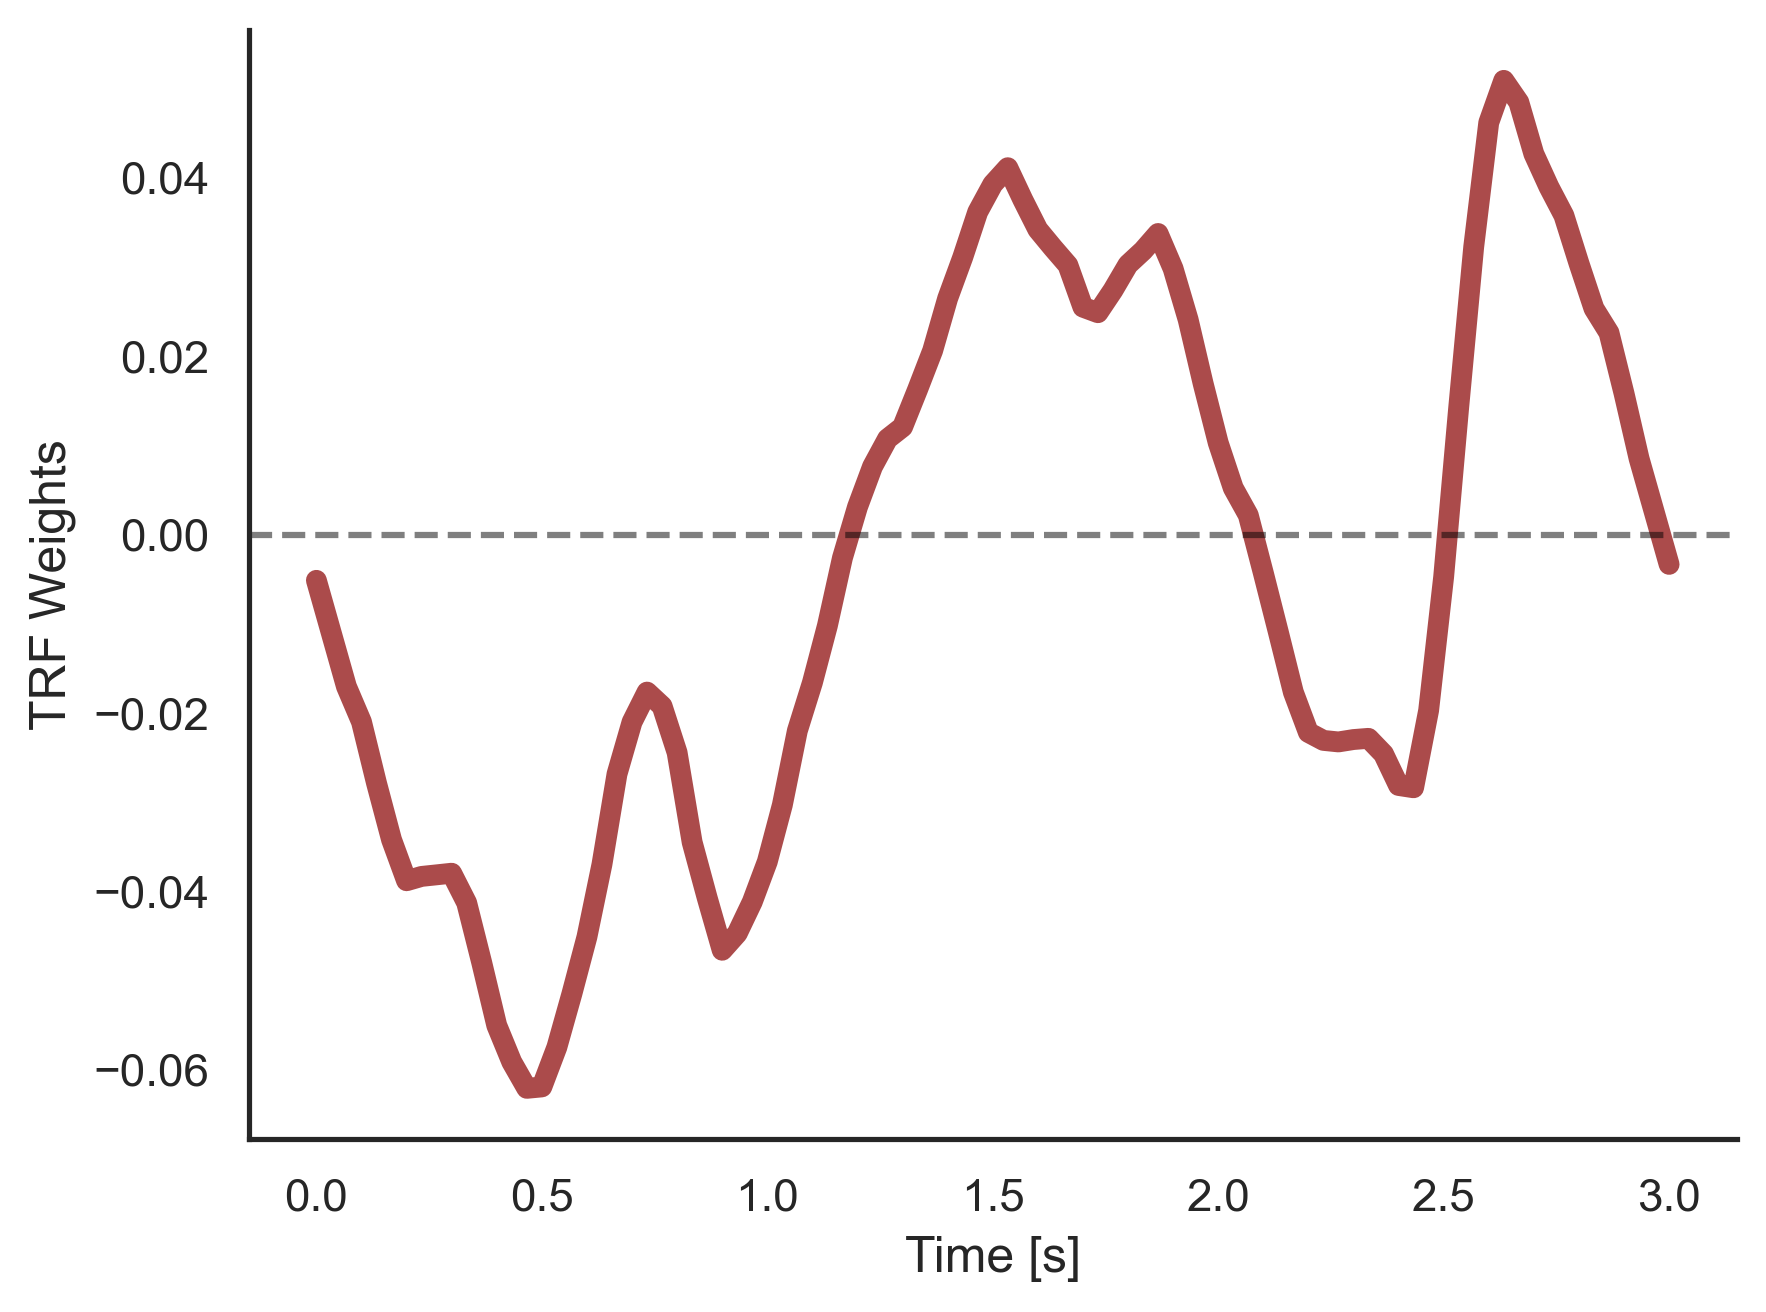

In [ ]:
# sns.lineplot(data=motion_trf_df, x="times", y=f"weights", c="#ab4b4b", lw=2, alpha=0.25, label="Original")
sns.lineplot(data=motion_trf_df, x="times", y=f"weights_smooth", c="#ab4b4b", lw=5)
plt.axhline(y=0, c="k", ls="--", alpha=0.5)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.xlabel("Time [s]")
plt.ylabel("TRF Weights")
# plt.legend()

### Listeners' sex-specific TRFs suggest faster responses from females by ~500ms

In [ ]:
male_motion_trf = train_single_trf(
    data=df.loc[(df.Condition=="true") & (df.ListenerSex=="M")], 
    input_col="Stimulus", output_col="Motion",
    min_lag=MIN_LAG, max_lag=MAX_LAG, sr=SR, reg=50,
    trim=True, scale=False
)
male_motion_trf_df = trf_to_df(male_motion_trf)
male_motion_trf_df["ListenerSex"] = "M"

female_motion_trf = train_single_trf(
    data=df.loc[(df.Condition=="true") & (df.ListenerSex=="F")], 
    input_col="Stimulus", output_col="Motion",
    min_lag=MIN_LAG, max_lag=MAX_LAG, sr=SR, reg=50,
    trim=True, scale=False
)
female_motion_trf_df = trf_to_df(female_motion_trf)
female_motion_trf_df["ListenerSex"] = "F"

combined_motion_trf_df = pd.concat([male_motion_trf_df, female_motion_trf_df])
combined_motion_trf_df["weights_smooth"] = savgol_filter(combined_motion_trf_df.weights, window_length=5, polyorder=1)

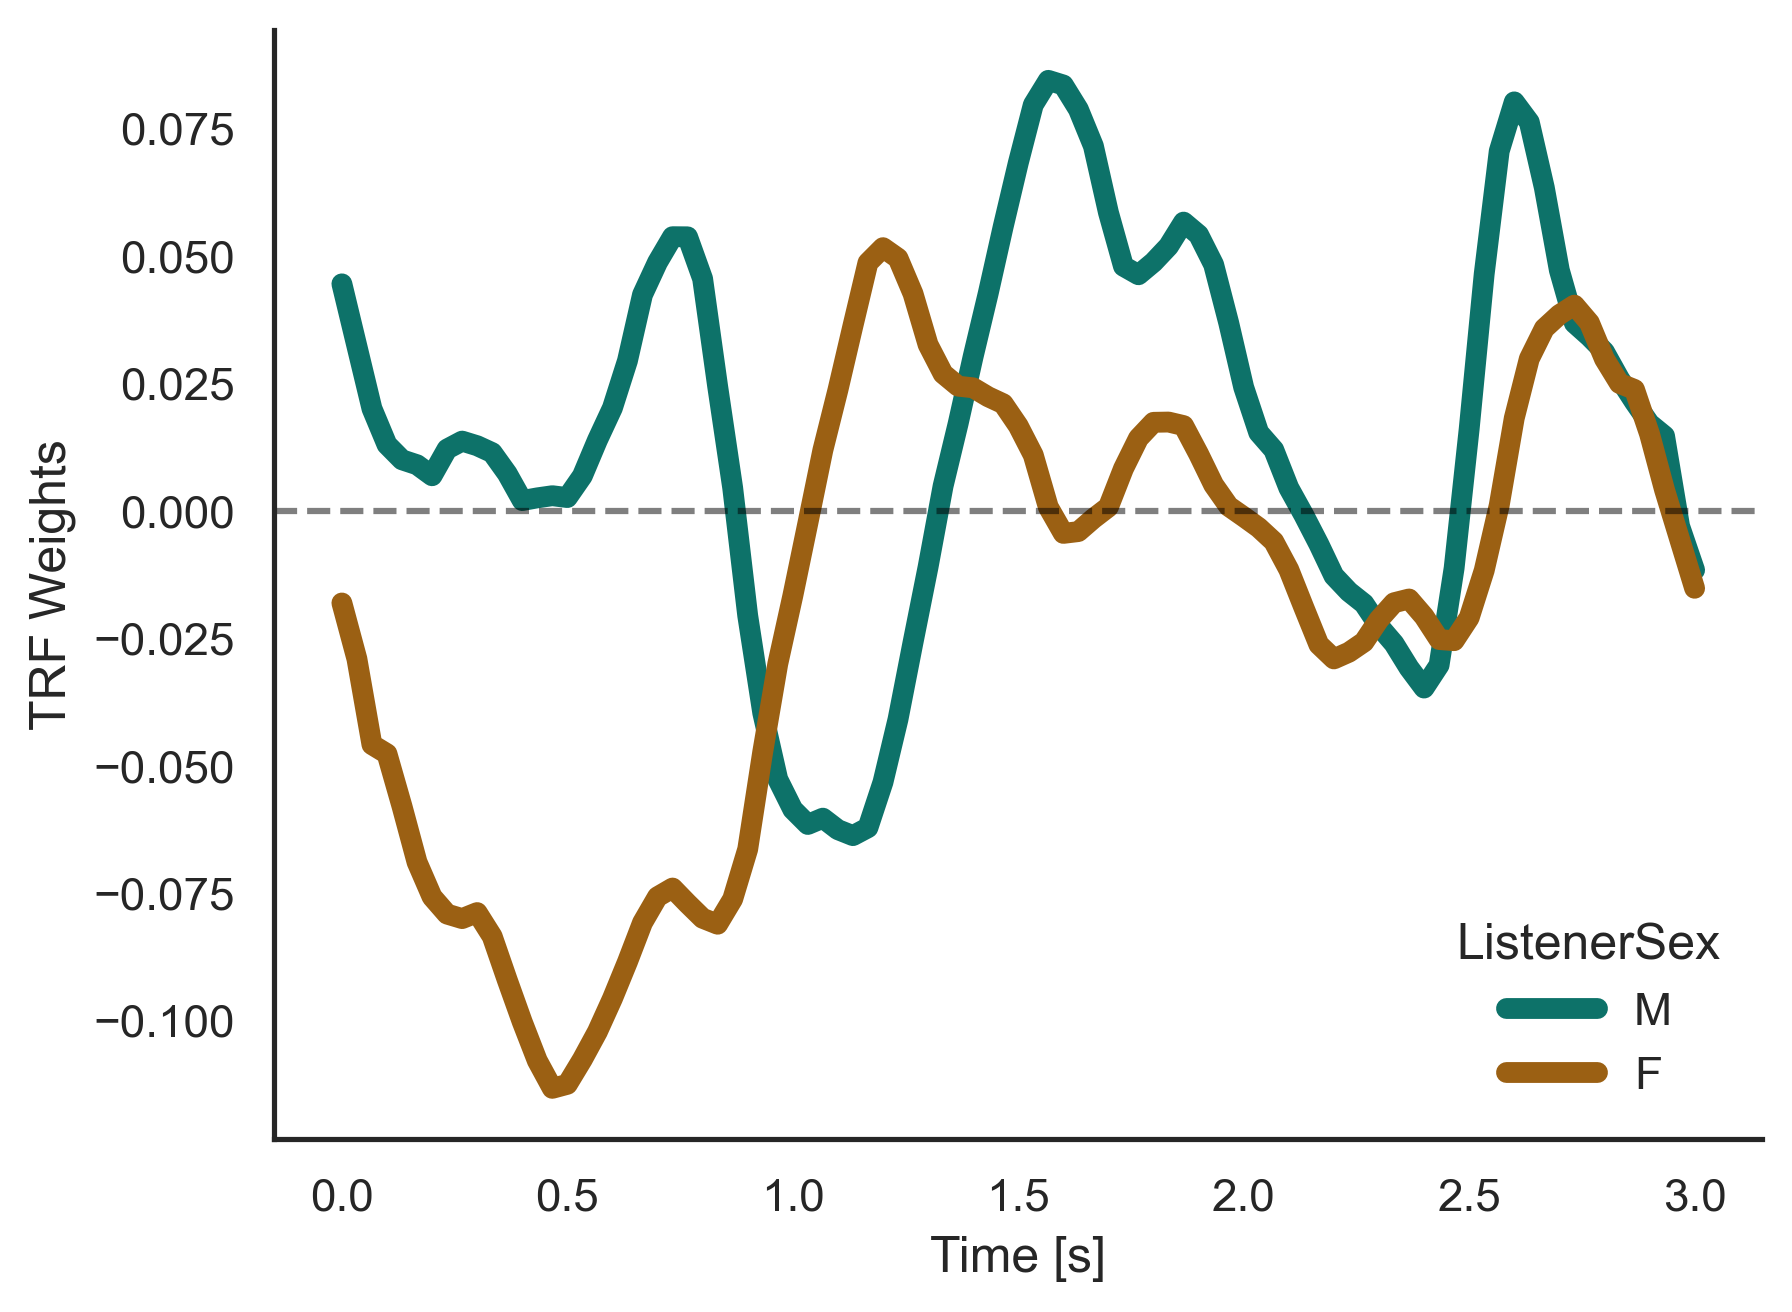

In [ ]:
# sns.lineplot(
#     data=combined_motion_trf_df, x="times", y="weights", hue="ListenerSex", 
#     palette=["#0d7269", "#9b6013"], lw=2, alpha=0.25
# )
sns.lineplot(
    data=combined_motion_trf_df, x="times", y="weights_smooth", hue="ListenerSex", 
    palette=["#0d7269", "#9b6013"], lw=5
)
plt.axhline(y=0, c="k", ls="--", alpha=0.5)
plt.legend(title="ListenerSex", frameon=False, loc="lower right")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.xlabel("Time [s]")
plt.ylabel("TRF Weights")

### Correlation between actual and predicted listener motion (TRF fit) is significantly lower in fake interactions

In [ ]:
# use motion TRF to predict responses to speech 
# and compute correlation between actual and predicted motion
df[["Prediction", "Fit"]] = df.apply(
    lambda x: motion_trf.predict(x.Stimulus, x.Motion), 
    axis=1, result_type="expand"
)
df["Prediction"] = df.Prediction.transform(lambda x: x[0].flatten())
# compute correlation between actual and predicted motion as predicted by the male-listener-TRF
df["MaleFit"] = df.apply(
    lambda x: male_motion_trf.predict(x.Stimulus, x.Motion)[1], 
    axis=1
)
# compute correlation between actual and predicted motion as predicted by the female-listener-TRF
df["FemaleFit"] = df.apply(
    lambda x: female_motion_trf.predict(x.Stimulus, x.Motion)[1], 
    axis=1
)

In [ ]:
ttest_alt_df = df.copy()
ttest_alt_df["Condition"] = ttest_alt_df.Condition.apply(lambda x: 1 if x=="true" else 0)

def fit_glmm_alt(formula, data):
    r_var = f"df_{uuid.uuid4().hex[:8]}"
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv[r_var] = ro.conversion.py2rpy(data.reset_index(drop=True))
    m = ro.r(f"lmer({formula}, data={r_var})")
    ro.r(f"rm({r_var})")

    return ro.r("summary")(m)

print(fit_glmm_alt(
    formula="Fit ~ Condition + (1|Dyad)",
    data=ttest_alt_df
))

/Users/rg/miniforge3/envs/speed_dating/lib/python3.14/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Stimulus". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '
/Users/rg/miniforge3/envs/speed_dating/lib/python3.14/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Motion". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '
/Users/rg/miniforge3/envs/speed_dating/lib/python3.14/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Prediction". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '
R callback write-console: boundary (singular) fit: see help('isSingular')
  


Linear mixed model fit by REML ['lmerMod']
Formula: Fit ~ Condition + (1 | Dyad)
   Data: df_62787073

REML criterion at convergence: -75.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9762 -0.7051 -0.0570  0.6508  3.2560 

Random effects:
 Groups   Name        Variance Std.Dev.
 Dyad     (Intercept) 0.00000  0.0000  
 Residual             0.03819  0.1954  
Number of obs: 200, groups:  Dyad, 57

Fixed effects:
            Estimate Std. Error t value
(Intercept) -0.03106    0.01954  -1.589
Condition    0.08276    0.02764   2.995

Correlation of Fixed Effects:
          (Intr)
Condition -0.707
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: see help('isSingular')




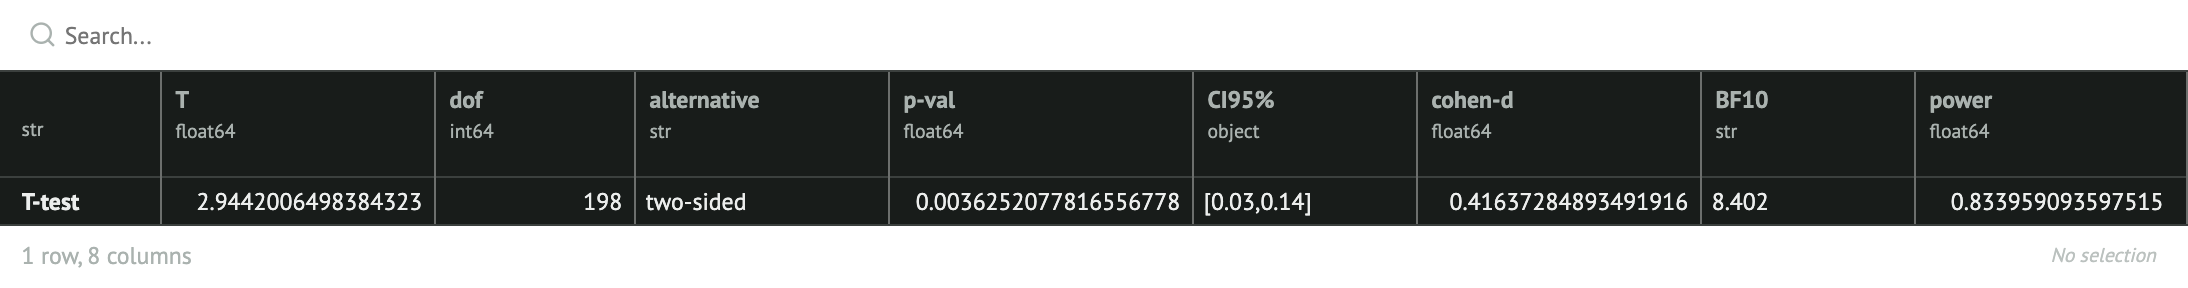

In [ ]:
pg.ttest(
    np.arctanh(df.loc[df.Condition=="true"].Fit.to_list()),
    np.arctanh(df.loc[df.Condition=="fake"].Fit.to_list()),
)

### An SVM trained on motion TRF fits performs above chance at classifying trials as genuine or fake

In [ ]:
X = df[["Fit"]].to_numpy()
y = df["Condition"].to_numpy()
X = StandardScaler().fit_transform(X)

# nested CV: inner loop tunes C, outer loop estimates accuracy
svc = SVC(kernel="linear", probability=True)
param_grid = {"C": np.logspace(-5, 3, 9)}

inner_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=4)
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=4)

# GridSearchCV wraps the inner loop
# cross_val_score wraps the outer loop
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", probability=True))
])
tuned_svc = GridSearchCV(pipeline, {"svc__C": np.logspace(-5, 3, 9)}, cv=inner_cv, n_jobs=-1)
scores = cross_val_score(tuned_svc, X, y, cv=outer_cv)

print(f"Accuracy: μ={scores.mean():.2f}, SD={scores.std():.2f}")
pg.ttest(scores, 0.5)

### Observer perception of genuineness is driven by the dynamics of listener motion rather than its average quantity or (lagged) correlation with speech

In [ ]:
def fit_glmm(formula, data):
    r_var = f"df_{uuid.uuid4().hex[:8]}"
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv[r_var] = ro.conversion.py2rpy(data.reset_index(drop=True))
    m = ro.r(f"glmer({formula}, data={r_var}, family=binomial)")
    ro.r(f"rm({r_var})")

    return ro.r("summary")(m)

In [ ]:
glmm_df = pd.merge(
    study1_df.loc[:, ["VideoPath", "Subject", "SDT", "Resp"]].reset_index(drop=True),
    df.loc[:, ["VideoPath", "Dyad", "ListenerSex", "Fit", "Intensity", "xCorr", "MaleFit", "FemaleFit"]],
    on="VideoPath"
)
glmm_df["Resp"] = glmm_df.apply(lambda x: 1 if x.SDT=="hit" or x.SDT=="fa" else 0, axis=1)
for col in ["Fit", "Intensity", "xCorr", "MaleFit", "FemaleFit"]:
    glmm_df[col] = zscore(glmm_df[col])

In [ ]:
print(fit_glmm(
    formula="Resp ~ Fit + Intensity + xCorr + (1|Subject) + (1|Dyad)",
    data=glmm_df
))

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: Resp ~ Fit + Intensity + xCorr + (1 | Subject) + (1 | Dyad)
   Data: df_7302db1e

      AIC       BIC    logLik -2*log(L)  df.resid 
   1625.2    1655.6    -806.6    1613.2      1182 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.7908 -0.9554  0.5847  0.9100  1.7517 

Random effects:
 Groups  Name        Variance Std.Dev.
 Dyad    (Intercept) 0.27145  0.5210  
 Subject (Intercept) 0.04137  0.2034  
Number of obs: 1188, groups:  Dyad, 57; Subject, 18

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)  
(Intercept)  0.06276    0.10488   0.598   0.5496  
Fit          0.17331    0.06774   2.558   0.0105 *
Intensity   -0.05732    0.06787  -0.845   0.3983  
xCorr        0.05825    0.06714   0.868   0.3857  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
          (Intr) Fit    Int

### Sex-specific TRFs suggest that observer responses are driven largely by motion in female-listener interactions

In [ ]:
print(fit_glmm(
    formula="Resp ~ MaleFit*ListenerSex + FemaleFit*ListenerSex + (1|Subject) + (1|Dyad)",
    data=glmm_df
))

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: Resp ~ MaleFit * ListenerSex + FemaleFit * ListenerSex + (1 |  
    Subject) + (1 | Dyad)
   Data: df_ca88871e

      AIC       BIC    logLik -2*log(L)  df.resid 
   1622.0    1662.6    -803.0    1606.0      1180 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.7554 -0.9515  0.5958  0.9069  2.0044 

Random effects:
 Groups  Name        Variance Std.Dev.
 Dyad    (Intercept) 0.27425  0.5237  
 Subject (Intercept) 0.04063  0.2016  
Number of obs: 1188, groups:  Dyad, 57; Subject, 18

Fixed effects:
                       Estimate Std. Error z value Pr(>|z|)    
(Intercept)             0.02663    0.12041   0.221 0.824950    
MaleFit                 0.09369    0.09068   1.033 0.301526    
ListenerSexM            0.01109    0.13331   0.083 0.933714    
FemaleFit               0.35125    0.09655   3.638 0.000275 ***
MaleFit:ListenerSexM    0.0905

## TRF analysis: speech -> AUs

In [ ]:
ACTION_UNITS = [
        "AU01", "AU02", "AU04", "AU05", "AU06", "AU09", 
        "AU10", "AU12", "AU14", "AU15", "AU17", "AU23", "AU24", "AU25", "AU26", "AU28", "AU43", 
        "Pitch"
    ]

In [ ]:
def get_aus(file, aus=None, resample_length=None):
    id = os.path.splitext(file)[0]
    data = pd.read_csv(f"{id}_aus.csv", usecols=["VideoPath"]+aus)

    if resample_length is not None:
        data = data.set_index("VideoPath")
        data = data.apply(lambda x: resample(x, num=resample_length)).reset_index(drop=True)
        # add back the VideoPath column so we can merge later
        data["VideoPath"] = file

    # reshape to a dataframe with a single row containing lists then index into row to return a Series
    data = data.groupby("VideoPath")[aus].agg(list).iloc[0]

    return data

In [ ]:
au_df = df.copy()
au_df = au_df.loc[~au_df.VideoPath.isin(['./stimuli/008/4_5_av_fake.mov', './stimuli/009/1_3_av_fake.mov'])].reset_index(drop=True)
au_df = au_df.loc[:, ["VideoPath", "AudioPath", "Duration", "Condition", "Dyad", "ListenerSex", "Stimulus"]]
au_df[ACTION_UNITS] = au_df.apply(
    lambda x: get_aus(x.AudioPath, aus=ACTION_UNITS, resample_length=len(x.Stimulus)),
    axis=1, result_type="expand"
)
au_df = au_df.melt(
    id_vars=["VideoPath", "AudioPath", "Duration", "Condition", "Dyad", "ListenerSex", "Stimulus"],
    var_name="AU", value_name="Response"
)
au_df["Intensity"] = au_df.Response.transform(lambda x: np.mean(np.abs(x)))
au_df["xCorr"] = au_df.apply(lambda x: xcorr(x.Stimulus, x.Response, max_abs=True)[1], axis=1)
au_df["Response"] = au_df.Response.transform(zscore)
au_df

### Visualize correlation between AUs (over all trials) in genuine interactions

In [ ]:
def au_corrs(data, au_col, value_col):
    aus = data[au_col].unique()
    au_arrays = {
        au: data.loc[data[au_col]==au, value_col].iloc[0]
        for au in aus
    }
    rows = []
    for x, y in itertools.combinations(aus, 2):
        r = np.corrcoef(au_arrays[x], au_arrays[y])[0][1]
        rows.append((x, y, r))

    return pd.DataFrame(rows, columns=["AU1", "AU2", "r"])

In [ ]:
corr_df = au_df.copy()
corr_df = corr_df.loc[corr_df.Condition=="true", ["VideoPath", "Condition", "AU", "Response"]]

corr_rows = []
for trial in corr_df.VideoPath.unique():
    corr_rows.append(
        au_corrs(data=corr_df.loc[corr_df.VideoPath==trial], au_col="AU", value_col="Response")
    )
actual_corrs = pd.concat(corr_rows)
# transform Pearson r values to Fischer z values
# clip before -1 and 1 because arctanh of those is inf
actual_corrs["r"] = np.arctanh(np.clip(actual_corrs.r.to_numpy(), -0.9999, 0.9999))
# combine AU columns
actual_corrs["AU"] = actual_corrs.AU1 + "-" + actual_corrs.AU2
# compute mean of z values for each AU combination
actual_corrs = actual_corrs.groupby("AU").apply(lambda x: np.mean(x.r)).reset_index(name="r")
# transform average z values back to Pearson r
actual_corrs["r"] = np.tanh(actual_corrs.r.to_numpy())
# split the combined AU column again for pivot
actual_corrs = actual_corrs.join(actual_corrs["AU"].str.split('-', n=1, expand=True).rename(columns={0:"AU1", 1:"AU2"}))
actual_corrs = actual_corrs.pivot(index="AU2", columns="AU1", values="r")

In [ ]:
sns.heatmap(data=actual_corrs, cmap="BrBG", center=0)

### Train separate TRF for each AU

In [ ]:
au_trfs = {
    au: train_single_trf(
        data=au_df.loc[(au_df.AU==au) & (au_df.Condition=="true")], input_col="Stimulus", output_col="Response",
        min_lag=MIN_LAG, max_lag=MAX_LAG, sr=SR, reg=50,
        trim=True
    )
    for au in au_df.AU.unique()
}

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=5, sharex=True, figsize=(20, 10))
plt.tight_layout(h_pad=2, w_pad=4)
for _, (AU, ax) in enumerate(zip(ACTION_UNITS, axs.ravel())):
    sns.lineplot(data=trf_to_df(au_trfs[AU]), x="times", y="weights", c="k", lw=5, ax=ax)
    ax.axhline(y=0, ls="--", c="k")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("TRF weights")
    ax.set_title(AU)

for ax in axs.ravel()[-2:]:
    ax.remove()

plt.gcf()

### Predict responses for each trial with each AU TRF

In [ ]:
au_df[["Prediction", "Fit"]] = au_df.apply(
    lambda x: au_trfs[x.AU].predict(x.Stimulus, x.Response), 
    axis=1, result_type="expand"
)
au_df["Prediction"] = au_df.Prediction.transform(lambda x: x[0].flatten())

In [ ]:
# test = au_df.copy()
# test = test.drop(columns=["Stimulus", "Response", "Prediction"])
# test

### TRFs help isolate low-level features (beyond listener motion) that physically differ in genuine and fake interactions

In [ ]:
def permute_data(data, rng, label_col, id_col, group_col, au_col):
    d = data.copy()
    d = d.groupby([id_col, group_col]).agg(list).reset_index()
    # if label col is lists of repeated elements just choose the first element
    if isinstance(d[label_col].iloc[0], (list, np.ndarray)):
        d[label_col] = d[label_col].transform(lambda x: x[0])

    d[label_col] = rng.permutation(d[label_col].to_list())
    d = d.explode(column=list(set(d.columns) - set([id_col, label_col, group_col])))

    return d

In [ ]:
def maxstat_perm_ttest(data, n_permutations, label_col, id_col, group_col, au_col):
    rng = np.random.default_rng()
    per_au_null_dist = []
    null_dist = np.zeros(n_permutations)

    for n in tqdm.tqdm(range(n_permutations)):
        permuted_data = permute_data(data, rng, label_col, id_col, group_col, au_col)
        res = permuted_data.groupby([au_col]).apply(
            lambda x: pg.ttest(
                x.loc[x.Condition=="true"].Corr.to_list(),
                x.loc[x.Condition=="fake"].Corr.to_list(),
            )
        ).reset_index()
        # null_dist[n] = np.max(np.abs(res["T"]))
        null_dist[n] = np.max(res["T"])
        per_au_null_dist.append(res)

    return null_dist, per_au_null_dist

In [ ]:
observed_t = au_df.groupby("AU").apply(
    lambda x: pg.ttest(
        np.arctanh(x.loc[x.Condition=="true"].Fit.to_list()),
        np.arctanh(x.loc[x.Condition=="fake"].Fit.to_list()),
    )
).reset_index()

# ------------------ MAXIMUM STATISTIC PERMUTATION TEST ------------------
# null_dist_ttest, per_au_res = maxstat_perm_ttest(
#     data=au_df, n_permutations=10000,
#     label_col="Condition", id_col="VideoPath", group_col="Condition", au_col="AU"
# )
# observed_t["p-val-corrected"] = observed_t.apply(
#     lambda x: np.mean(null_dist_ttest >= np.abs(x["T"])), 
#     axis=1
# )
# ------------------ TRADITIONAL MULTIPLE COMPARISONS CORRECTION ------------------
observed_t["p-val-corrected"] = pg.multicomp(observed_t["p-val"], method="fdr_bh")[1]

observed_t.loc[(observed_t["p-val"]<0.05) | (observed_t["p-val-corrected"]<0.05)]

In [ ]:
svm_aus_df = au_df.loc[:, ["VideoPath", "Condition", "AU", "Fit"]].pivot(
    index=["VideoPath", "Condition"], columns="AU", values="Fit"
)
X_aus = svm_aus_df.to_numpy()
y_aus = svm_aus_df.reset_index()["Condition"].to_numpy()

# nested CV: inner loop tunes C, outer loop estimates accuracy
svc_aus = SVC(kernel="linear", probability=True)
param_grid_aus = {"C": np.logspace(-5, 3, 9)}

inner_cv_aus = StratifiedKFold(n_splits=10, shuffle=True, random_state=4)
outer_cv_aus = StratifiedKFold(n_splits=10, shuffle=True, random_state=4)

pipeline_aus = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", probability=True))
])

tuned_svc_aus = GridSearchCV(pipeline_aus, {"svc__C": np.logspace(-5, 3, 9)}, cv=inner_cv_aus, n_jobs=-1)
scores_aus = cross_val_score(tuned_svc_aus, X_aus, y_aus, cv=outer_cv_aus)

print(f"Accuracy: μ={scores_aus.mean():.2f}, SD={scores_aus.std():.2f}")
pg.ttest(scores_aus, 0.5)

### TRFs also help isolate low-level features that drive perceived genuineness of interactions

In [ ]:
def parse_formula(formula):
    # strip all whitespace
    formula = formula.replace(" ", "")
    dv, f = formula.split("~")
    # split RHS and discard random effects
    # split again to get list if fixed effects
    ivs = f.split("+(")[0].split("+")
    # ivs = [iv.split("*")[0] for iv in ivs]

    return dv, ivs

In [ ]:
def extract_coefs(model, au):
    coef_matrix = base.summary(model).rx2('coefficients')
    coef_pd = pd.DataFrame(
        np.array(coef_matrix),
        index=list(coef_matrix.rownames),
        columns=list(coef_matrix.colnames),
    )
    rows = []
    for param in coef_pd.index:
        if param == "(Intercept)":
            continue
        row = coef_pd.loc[param]
        rows.append({
            "AU": au, "IV": param,
            "Coef": row["Estimate"], "Zstat": row["z value"], "p-val": row["Pr(>|z|)"]
        })

    return pd.DataFrame(rows)

In [ ]:
def maxstat_perm_glmm(data, formula, n_permutations, label_col, id_col, group_col, au_col):
    rng = np.random.default_rng()
    dv, ivs = parse_formula(formula)
    null_dist = {iv: np.zeros(n_permutations) for iv in ivs}

    for n in tqdm.tqdm(range(n_permutations)):
        permuted_data = permute_data(data, rng, label_col, id_col, group_col, au_col)
        au_models = []
        for au in permuted_data[au_col].unique():
            temp_df = permuted_data.loc[permuted_data[au_col]==au]
            for el in ["Fit", "Intensity", "xCorr"]:
                temp_df[el] = zscore(temp_df[el].to_list())
            model = fit_glmm(formula=formula, data=temp_df)
            au_models.append(extract_coefs(model, au))

        res = pd.concat(au_models)
        for iv in ivs:
            null_dist[iv][n] = np.max(np.abs(res.loc[res.IV==iv, "Zstat"]))

    return null_dist

In [ ]:
au_glmm_df = pd.merge(
    study1_df.loc[:, ["VideoPath", "Subject", "SDT", "Resp"]].reset_index(drop=True),
    au_df.loc[:, ["VideoPath", "Duration", "Dyad", "ListenerSex", "AU", "Fit", "Intensity", "xCorr"]],
    on="VideoPath"
)
au_glmm_df["Resp"] = au_glmm_df.apply(lambda x: 1 if x.SDT=="hit" or x.SDT=="fa" else 0, axis=1)
au_glmm_df = au_glmm_df.drop(columns=["SDT", "ListenerSex"])
au_glmm_df

In [ ]:
FORMULA = "Resp ~ Fit + Intensity + xCorr + (1|Subject) + (1|Dyad)"

au_models = []
for au in au_glmm_df.AU.unique():
    temp_df = au_glmm_df.loc[au_glmm_df.AU==au]
    for el in ["Fit", "Intensity", "xCorr"]:
        temp_df[el] = zscore(temp_df[el])

    model = fit_glmm(formula=FORMULA, data=temp_df)
    au_models.append(extract_coefs(model, au))

observed_fits = pd.concat(au_models)

# ------------------ MAXIMUM STATISTIC PERMUTATION TEST ------------------
# null_dist_glmm = maxstat_perm_glmm(
#     data=au_glmm_df, n_permutations=1000, 
#     label_col="Resp", id_col="VideoPath", group_col="Subject", au_col="AU", formula=FORMULA
# )
# observed_fits["p-val-corrected"] = observed_fits.apply(
#     lambda x: np.mean(null_dist_glmm[x.IV] >= np.abs(x.Zstat)), 
#     axis=1
# )

# ------------------ TRADITIONAL MULTIPLE COMPARISONS CORRECTION ------------------
for iv in observed_fits.IV.unique():
    mask2 = observed_fits.IV == iv
    observed_fits.loc[mask2, "p-val-corrected"] = pg.multicomp(
        observed_fits.loc[mask2, "p-val"].to_list(), 
        method="fdr_bh"
    )[1]

observed_fits
    # .loc[(observed_fits["p-val"]<0.05) | (observed_fits["p-val-corrected"]<0.05)]

# Study 2

Subjects with issues during experiment (incomplete experiment):

- Eyes: [5, 50, 660c0269f4ac950966a37c9d, 1007]
- Mouth: [65, 77, 88, 114, 124]
- Original: [248, 249, 268, 270, 271, 283, 291]

Subjects with same response in every trial: [78, 135]

These participants have been remove from the following analysis. Participants with the same IDs may appear in the data but they are not the same.

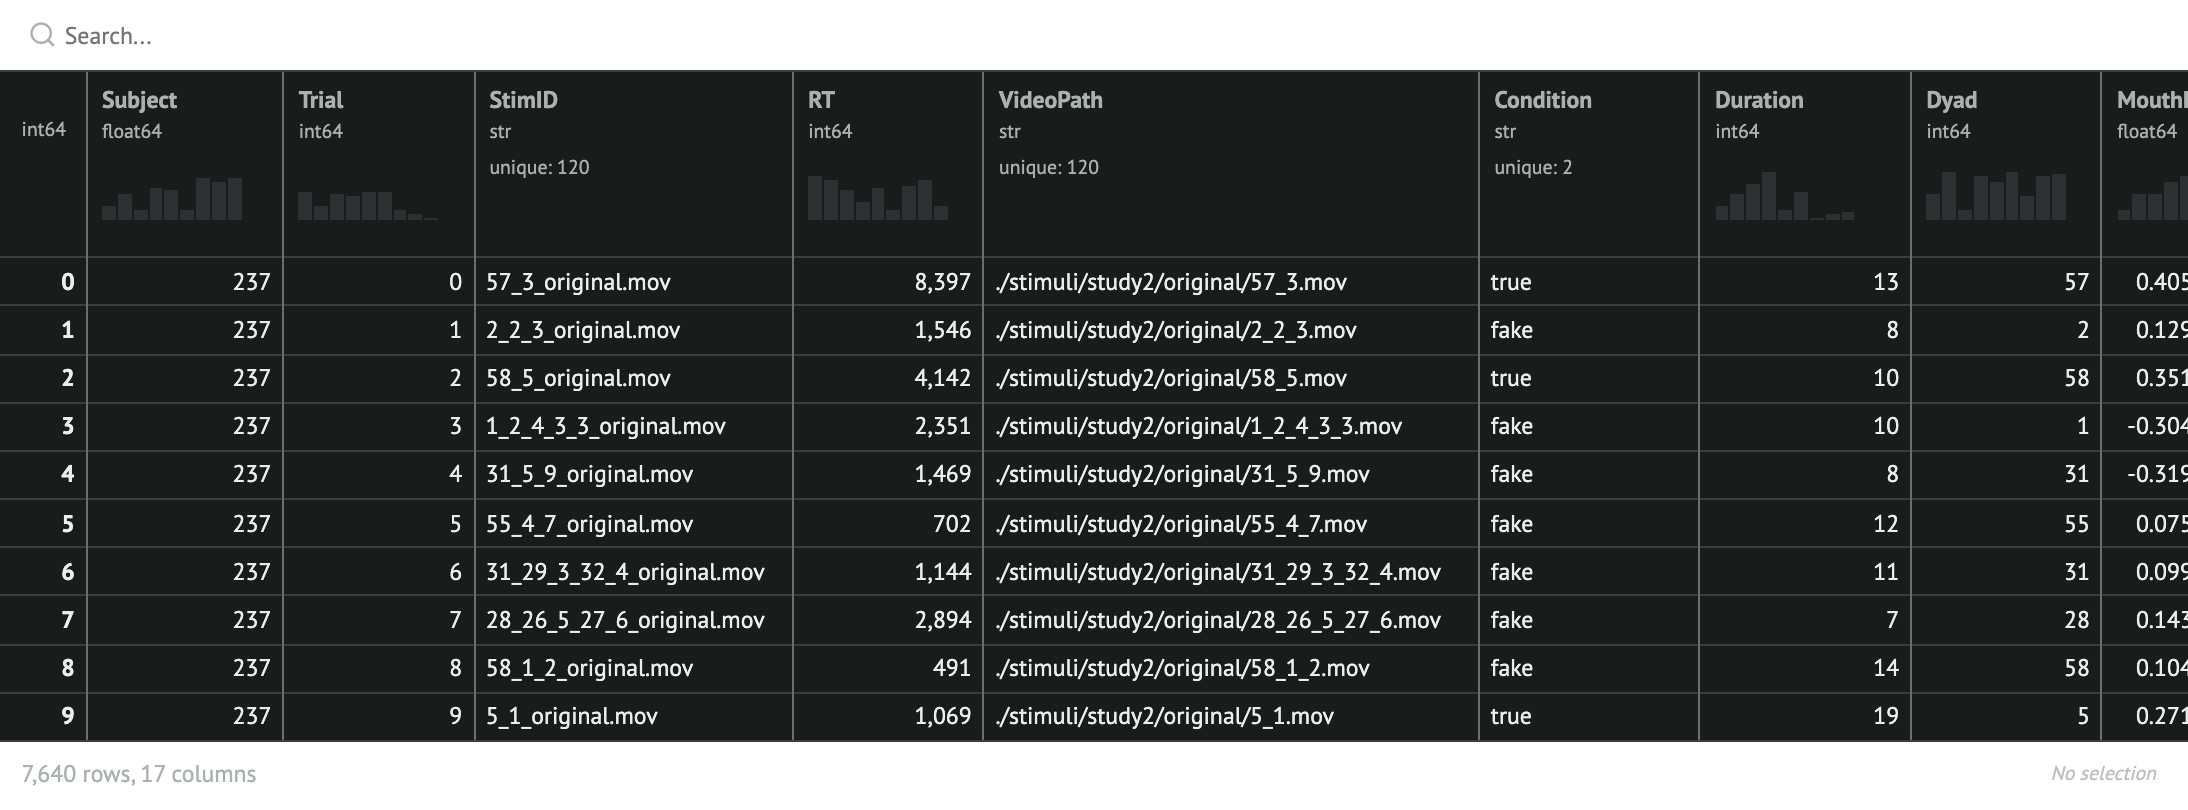

In [ ]:
study2_df = pd.concat(
    [
        pd.read_csv(file) 
        for file in glob("./responses/study2/new/*.csv")
    ], 
    ignore_index=True
)
exclude_study2 = [
    53, 56,          # eyes
    86, 109, 112,    # mouth
    264,             # original
]
study2_df = study2_df.loc[~study2_df.Subject.isin(exclude_study2)]
study2_df = study2_df.drop(columns="Unnamed: 0")
study2_df

## Observers can recognize genuine interactions even when either the eyes or the mouth is masked

In [ ]:
dprime_df2 = study2_df.groupby(["Subject", "Block"], as_index=False).SDT.apply(sdt_rates)

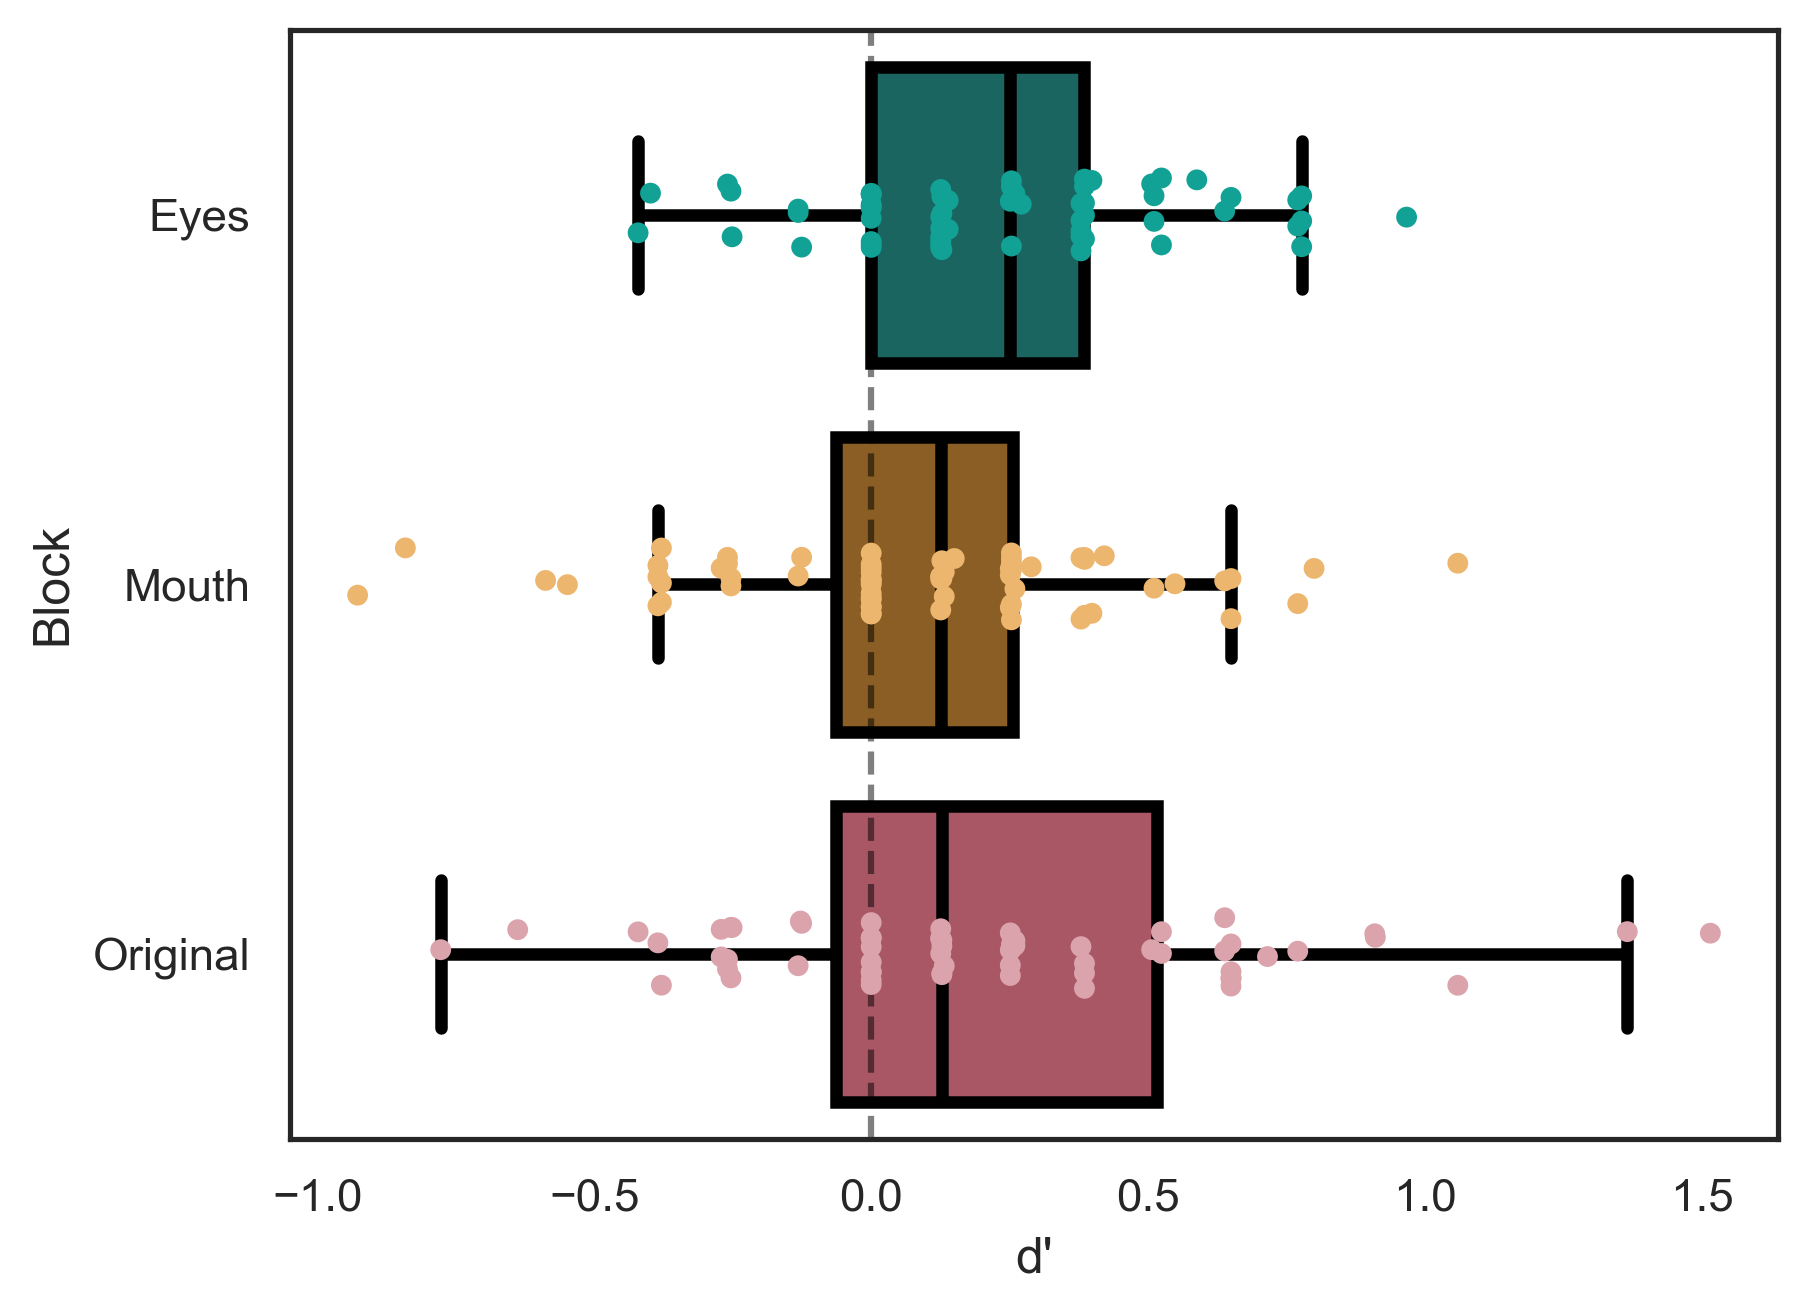

In [ ]:
sns.boxplot(
    data=dprime_df2, y="Block", x="dprime", hue="Block", 
    order=["eyes", "mouth", "original"], fill=True,
    palette=["#0d7269", "#9b6013", "#b64a5c"],
    fliersize=0, linewidth=3, linecolor="k"
)
sns.stripplot(data=dprime_df2, y="Block", x="dprime", hue="Block", palette=["#12a195", "#edb66e", "#dba4ad"], jitter=True)
plt.axvline(x=0, c="k", ls="--", alpha=0.5)
plt.xlabel("d'")
plt.yticks(ticks=[0, 1, 2], labels=["Eyes", "Mouth", "Original"])
plt.ylabel("Block")

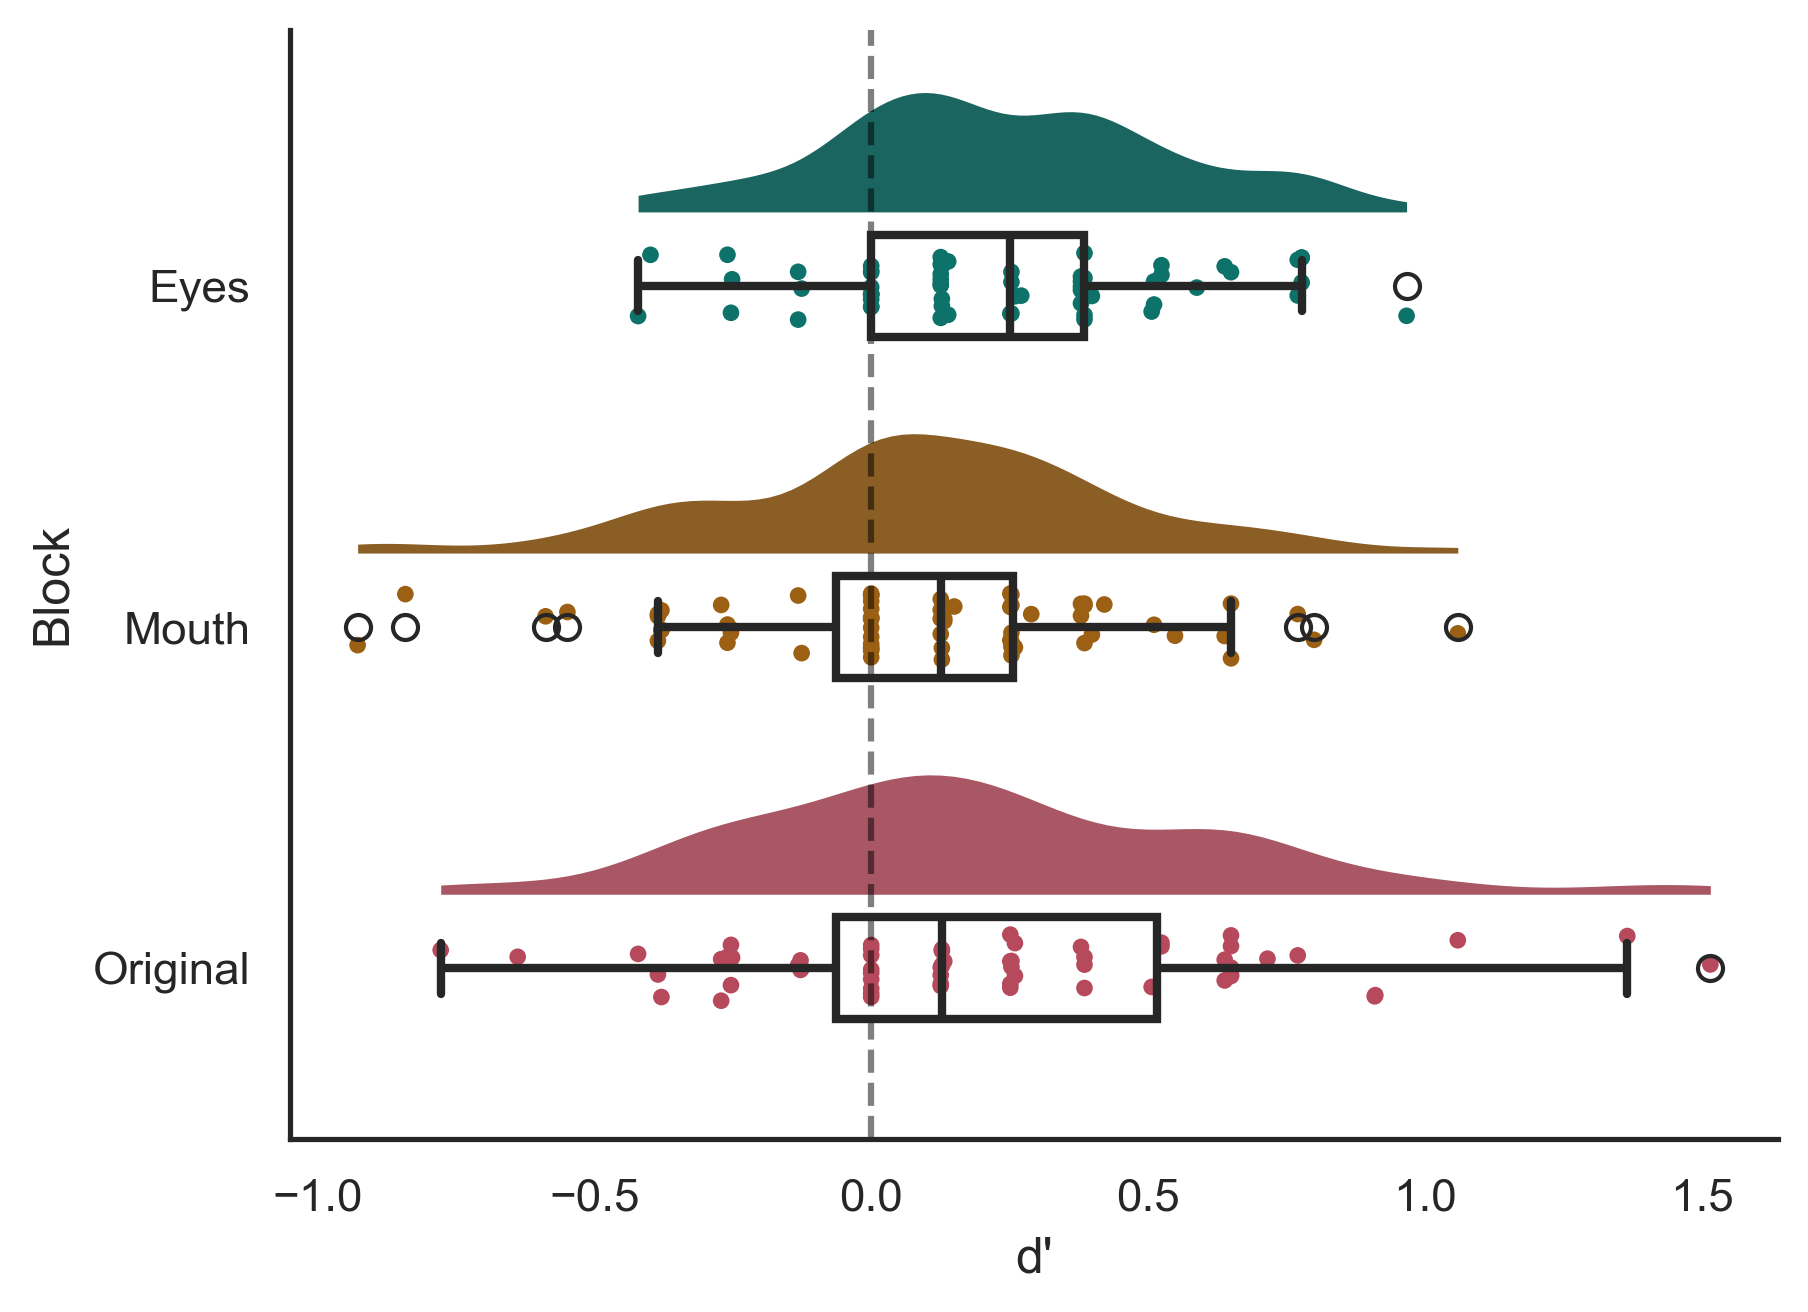

In [ ]:
pt.RainCloud(
    data=dprime_df2, x="Block", y="dprime", palette=["#0d7269", "#9b6013", "#b64a5c"], hue="Block", orient="h",
    order=["eyes", "mouth", "original"], hue_order=["eyes", "mouth", "original"], linewidth=0, bw=0.3, 
    width_box=0.3, box_linewidth=2, point_size=4
)
plt.axvline(x=0, c="k", ls="--", alpha=0.5)
plt.xlabel("d'")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks(ticks=[0, 1, 2], labels=["Eyes", "Mouth", "Original"])
plt.gcf()

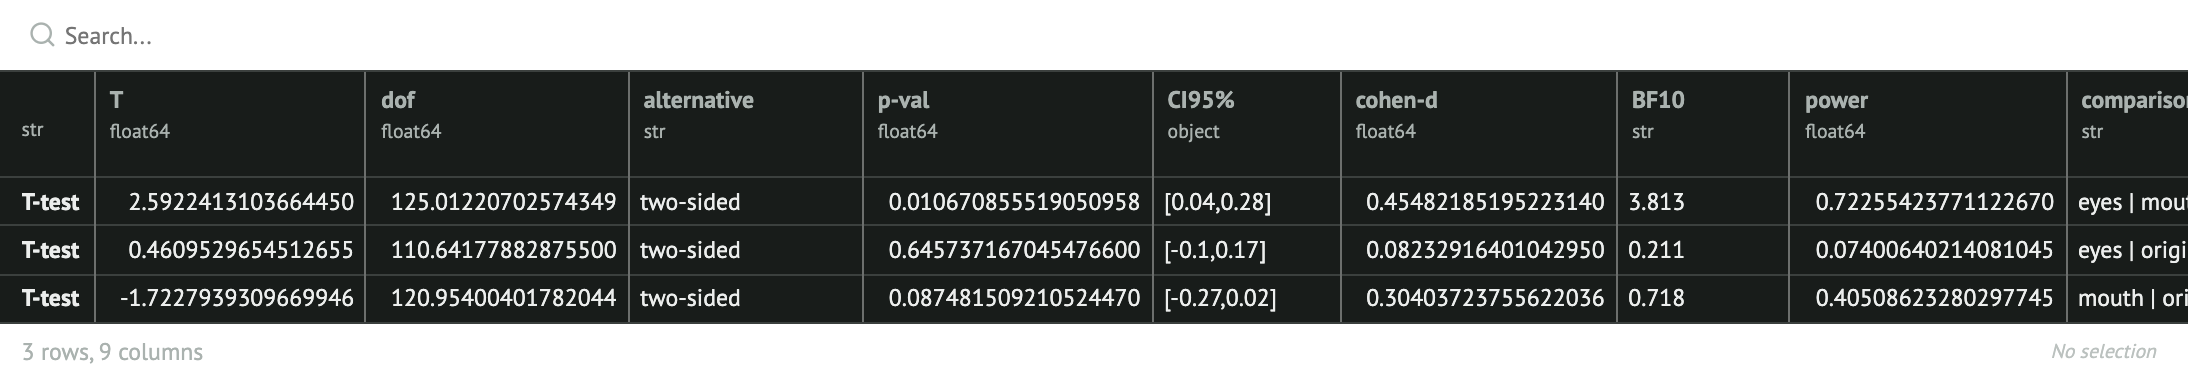

In [ ]:
pairwise_ttest(data=dprime_df2, dv="dprime", between="Block")

## Observer perception of genuineness is driven by the dynamics of listener motion more strongly when the eyes are visible

In [ ]:
def parse_trial_name(filename):
    dyad, file = filename.split("/")[-2:]
    dyad = int(dyad)
    file = file.split(".")[0]

    return f"{dyad}_{file}.mov"

In [ ]:
study1_motion = df.loc[:, ["AudioPath", "Duration", "Condition", "Stimulus", "Prediction"]]
study1_motion["BaseVideo"] = study1_motion.AudioPath.transform(parse_trial_name)
study1_motion = study1_motion.drop(columns="AudioPath")

study2_motion = pd.read_parquet("./stimuli/study2/motion.parquet")
study2_motion["BaseVideo"] = study2_motion.VideoPath.transform(lambda x: x.split("/")[-1])
study2_motion["VideoPath"] = study2_motion.VideoPath.transform(lambda x: "./stimuli/study2/"+x)

study2_motion = pd.merge(study1_motion, study2_motion, on="BaseVideo")
# resample study2 motion time-series to same length as study1 time-series
study2_motion["Motion"] = study2_motion.apply(lambda x: resample(x.Motion, num=len(x.Prediction)), axis=1)
# add column for intensity as control
study2_motion["Intensity"] = study2_motion.Motion.transform(lambda x: np.mean(np.abs(x)))
# add column for lagged cross-correlation between input and output as control
study2_motion[["best_lag", "xCorr"]] = study2_motion.apply(
    lambda x: xcorr(x.Stimulus, x.Motion, max_abs=True), 
    axis=1, result_type="expand"
)
# standardize each response individually
study2_motion["Motion"] = study2_motion.Motion.transform(zscore)
study2_motion["Fit"] = study2_motion.apply(lambda x: np.corrcoef(x.Motion, x.Prediction)[0, 1], axis=1)

In [ ]:
glmm_df1 = pd.merge(
    study2_df.loc[:,["VideoPath", "Condition", "Block", "Subject", "Dyad", "SDT", "Resp"]],
    study2_motion,
    on="VideoPath"
)
glmm_df1["Resp"] = glmm_df1.apply(lambda x: 1 if x.SDT=="hit" or x.SDT=="fa" else 0, axis=1)
glmm_df1 = glmm_df1.drop(columns=["SDT", "BaseVideo", "Stimulus", "Prediction", "Motion"])
for col1 in ["Fit", "Intensity", "xCorr"]:
    glmm_df1[col1] = zscore(glmm_df1[col1])

In [ ]:
# import pickle
# with open("./study2responses_motion_rms.pkl", "wb") as f:
#     pickle.dump(obj=glmm_df1, file=f)

In [ ]:
print(fit_glmm(
    formula="Resp ~ Fit * Block + Intensity + xCorr + (1 | Subject) + (1 | Dyad)",
    data=glmm_df1.reset_index(drop=True)
))

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: Resp ~ Fit * Block + Intensity + xCorr + (1 | Subject) + (1 |  
    Dyad)
   Data: df_f3c1aff3

      AIC       BIC    logLik -2*log(L)  df.resid 
  10184.6   10254.0   -5082.3   10164.6      7630 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.7144 -0.9707  0.6156  0.8956  1.5965 

Random effects:
 Groups  Name        Variance Std.Dev.
 Subject (Intercept) 0.004566 0.06757 
 Dyad    (Intercept) 0.282336 0.53135 
Number of obs: 7640, groups:  Subject, 191; Dyad, 29

Fixed effects:
                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)        0.104506   0.108906   0.960  0.33726    
Fit                0.256988   0.064480   3.986 6.73e-05 ***
Blockmouth        -0.001850   0.059564  -0.031  0.97523    
Blockoriginal     -0.001257   0.079809  -0.016  0.98743    
Intensity          0.013500   0.044610   0.303  0.76217    
xCorr

In [ ]:
sns.kdeplot(data=glmm_df1.loc[glmm_df1.Block=="eyes"], x="best_lag", hue="Condition_x", fill=True, hue_order=["true", "fake"])

In [ ]:
study2_motion["Block"] = study2_motion.VideoPath.transform(lambda x: x.split("/")[3])

eyes_motion_trf = train_single_trf(
    data=study2_motion.loc[(study2_motion.Condition=="true") & (study2_motion.Block=="eyes")], 
    input_col="Stimulus", output_col="Motion",
    min_lag=MIN_LAG, max_lag=MAX_LAG, sr=SR, reg=50,
    trim=True, scale=False
)
mouth_motion_trf = train_single_trf(
    data=study2_motion.loc[(study2_motion.Condition=="true") & (study2_motion.Block=="mouth")], 
    input_col="Stimulus", output_col="Motion",
    min_lag=MIN_LAG, max_lag=MAX_LAG, sr=SR, reg=50,
    trim=True, scale=False
)
original_motion_trf = train_single_trf(
    data=study2_motion.loc[(study2_motion.Condition=="true") & (study2_motion.Block=="original")], 
    input_col="Stimulus", output_col="Motion",
    min_lag=MIN_LAG, max_lag=MAX_LAG, sr=SR, reg=50,
    trim=True, scale=False
)
study2_motion_trf_df = pd.concat([
    trf_to_df(v, label=k)
    for k, v in {"eyes": eyes_motion_trf, "mouth": mouth_motion_trf, "original": original_motion_trf}.items()
])
study2_motion_trf_df = study2_motion_trf_df.rename(columns={"label": "Block"}) 
study2_motion_trf_df["weights_smooth"] = savgol_filter(study2_motion_trf_df.weights, window_length=5, polyorder=1)

In [ ]:
sns.lineplot(data=motion_trf_df, x="times", y=f"weights_smooth", c="k", lw=5, label="Study 1")
sns.lineplot(data=study2_motion_trf_df, x="times", y=f"weights_smooth", c="#ab4b4b", lw=5, hue="Block")
plt.axhline(y=0, c="k", ls="--", alpha=0.5)
plt.xlabel("Time [s]")
plt.ylabel("TRF Weights")
plt.legend()

In [ ]:
glmm_df1.to_pickle("./speed_dating_study2_responses.pkl")

# Test revcor TRF

In [ ]:
from cleese_stim.engines.phase_vocoder import utils as pvutils
from cleese_stim.engines.trf_warp import base_utils

In [ ]:
revcor_trf = pd.read_csv("./trf_smoothed.csv")
revcor_trf["kernel_value_smooth"] = MaxAbsScaler().fit_transform(np.reshape(revcor_trf.kernel_value_smooth.to_numpy(), (-1, 1)))

sd_trf = motion_trf_df.copy()
sd_trf["weights_smooth_scaled"] = MaxAbsScaler().fit_transform(np.reshape(sd_trf.weights_smooth.to_numpy(), (-1, 1)))

sns.lineplot(data=revcor_trf, x="feature", y="kernel_value_smooth", lw=5, c="k", label="Revcor")
sns.lineplot(data=sd_trf, x="times", y=f"weights_smooth_scaled", c="#ab4b4b", lw=5, label="Speed Dating")
plt.axhline(y=0, c="k", ls="--")

In [ ]:
def revcor_predict(row, trf):
    trf_array = trf.loc[:, ["feature", "kernel_value_smooth"]].to_numpy()
    stim = np.vstack([
        np.linspace(0, row.Duration, num=len(row.Stimulus)).flatten(),
        row.Stimulus
    ]).T
    pred = base_utils.compute_gain(rms=stim, trf=trf_array)[:, 1]
    # r = np.corrcoef(row.Motion, pred)[0, 1]

    return pred

In [ ]:
revcor_df = df.copy()
revcor_df["RevcorPred"] = revcor_df.apply(lambda x: revcor_predict(x, revcor_trf), axis=1)
revcor_df["RevcorFit"] = revcor_df.apply(lambda x: np.corrcoef(x.Motion, x.RevcorPred)[0, 1], axis=1)

pg.corr(revcor_df.Fit, revcor_df.RevcorFit)

In [ ]:
sns.kdeplot(data=revcor_df, x="Fit", fill=True, label="Speed Dating TRF Fits")
sns.kdeplot(data=revcor_df, x="RevcorFit", fill=True, label="Revcor TRF Fits")
plt.legend()

In [ ]:
revcor_glmm = pd.merge(glmm_df, revcor_df.loc[:, ["VideoPath", "RevcorFit"]], on="VideoPath")
revcor_glmm["RevcorFit"] = zscore(revcor_glmm.RevcorFit)

In [ ]:
print(fit_glmm(
    formula="Resp ~ Fit + Intensity + xCorr + (1 | Subject) + (1 | Dyad)",
    data=revcor_glmm.reset_index(drop=True)
))

In [ ]:
print(fit_glmm(
    formula="Resp ~ RevcorFit + Intensity + xCorr + (1 | Subject) + (1 | Dyad)",
    data=revcor_glmm.reset_index(drop=True)
))

In [ ]:
# specifically look at 004/3_1 and 052/3 actual motion vs. predicted motion by revcorTRF
# get actual motion in study 2 trials
# use revcorTRF to predict responses
# compute correlation between actual and predicted
# fit GLMM

In [ ]:
df_a = study2_motion.copy()
df_a["RevcorPred"] = df_a.apply(lambda x: revcor_predict(x, revcor_trf), axis=1)
df_a["RevcorFit"] = df_a.apply(lambda x: np.corrcoef(x.Motion, x.RevcorPred)[0, 1], axis=1)
df_a["Block"] = df_a.VideoPath.transform(lambda x: x.split("/")[-2])

df_b = glmm_df1.copy()
df_b = df_b.loc[:, ["VideoPath", "Block", "Subject", "Dyad", "Resp"]]
df_b["BaseVideo"] = df_b.VideoPath.transform(lambda x: x.split("/")[-1])
df_b["Block"] = df_b.VideoPath.transform(lambda x: x.split("/")[-2])

df_ab = pd.merge(df_a, df_b, on=["BaseVideo", "Block"])
df_ab

In [ ]:
print(fit_glmm(
    formula="Resp ~ Fit*Block + Intensity + xCorr + (1 | Subject) + (1 | Dyad)",
    data=df_ab
))

In [ ]:
print(fit_glmm(
    formula="Resp ~ RevcorFit*Block + Intensity + xCorr + (1 | Subject) + (1 | Dyad)",
    data=df_ab
))